In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm openpyxl -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Cell 2: Data loaded directly from Datasets folder.
# Running locally.

In [3]:
# Cell 3: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [4]:
# Cell 4: Load Sheet1 and Sheet2 and combine them
# Sheet1 has 'Patient ID' column, Sheet2 does not — we drop it before merging
import os
DATASET_PATH = os.path.join("..", "Datasets", "COPD_Dataset.xlsx")

df1 = pd.read_excel(DATASET_PATH, sheet_name='Sheet1')
df2 = pd.read_excel(DATASET_PATH, sheet_name='Sheet2')

# Drop Patient ID if present
if 'Patient ID' in df1.columns:
    df1 = df1.drop(columns=['Patient ID'])

df = pd.concat([df1, df2], ignore_index=True)
print(f"✅ Sheet1: {df1.shape} | Sheet2: {df2.shape} | Combined: {df.shape}")
print("\nAll columns:")
for i, c in enumerate(df.columns):
    print(f"  [{i:02d}] {c}")

✅ Sheet1: (1166, 58) | Sheet2: (1068, 58) | Combined: (2234, 58)

All columns:
  [00] Gender
  [01] Age
  [02] Heigt(cm)
  [03] Height(in)
  [04] weight kg
  [05] weight (lb)
  [06] BMI
  [07] Smoker
  [08] Comorbidity1
  [09] Comorbidity 2
  [10] Comorbidity 3
  [11] COPD Medication
  [12] Baseline Dyspnea (mMRC)
  [13] COPD Gold Stage
  [14] Baseline heartrate
  [15] H Reserve
  [16] Heartrate Max
  [17] HR During light exercise
  [18] HR During moderate exercise
  [19] HR During vigorous exercise
  [20] Baseline temperature
  [21] Baseline temperature C
  [22] T During light exercise
  [23] T During moderate exercise
  [24] T During vigorous exercise
  [25] Baseline SpO2
  [26] SpO2 During light exercise
  [27] SpO2 During moderate exercise
  [28] SpO2 During vigorous exercise
  [29] Baseline  PaO2
  [30]  PaO2 During light exercise
  [31] PaO2During moderate exercise
  [32] PaO2 During vigorous exercise
  [33] Baseline PaCO2
  [34] PaCO2 During light exercise
  [35] PaCO2 During mo

In [5]:
# Cell 5: Select features matching the COPD clinical parameters from Image 2
# COPD features: Age, Gender, Smoking Status, BMI, FVC(L), FEV1(L),
#                FEV1/FVC Ratio, SpO2(%), Respiratory Rate, Cough(Y/N), Dyspnea Score

# From the dataset:
# - Age                   → 'Age'
# - Gender                → 'Gender'
# - Smoking Status        → 'Smoker'
# - BMI                   → 'BMI'
# - FEV1 (L)              → 'Baseline FEV1'  (Current FEV1 has messy string format)
# - SpO2 (%)              → 'Baseline SpO2'
# - Respiratory Rate      → 'Baseline Respiration Rate'
# - Dyspnea Score         → 'Baseline Dyspnea (mMRC)'  (mMRC1–mMRC5)
# - Cough (Y/N)           → NOT directly in dataset; we use comorbidities as proxy
# - FVC (L)               → NOT present; we'll approximate FEV1/FVC from GOLD stage
# - TARGET                → 'COPD Gold Stage' (Stage 1 / 2 / 3 / 4)

FEATURES = [
    'Age',
    'Gender',
    'Smoker',
    'BMI',
    'Baseline FEV1',         # FEV1 (L)
    'Baseline SpO2',         # SpO2 (%)
    'Baseline Respiration Rate',   # Respiratory Rate
    'Baseline Dyspnea (mMRC)',     # Dyspnea Score (mMRC scale)
    'Baseline heartrate',          # Additional clinical signal
]
TARGET = 'COPD Gold Stage'

df_model = df[FEATURES + [TARGET]].copy()
print(f"✅ Working DataFrame shape: {df_model.shape}")
print(f"\nTarget distribution:\n{df_model[TARGET].value_counts()}")
df_model.head()

✅ Working DataFrame shape: (2234, 10)

Target distribution:
COPD Gold Stage
Stage 2    1356
Stage 3     309
Stage 1     298
Stage 4     271
Name: count, dtype: int64


,Age,Gender,Smoker,BMI,Baseline FEV1,Baseline SpO2,Baseline Respiration Rate,Baseline Dyspnea (mMRC),Baseline heartrate,COPD Gold Stage
0,88,Male,No,23.746689,0.729397,95.173109,42.055429,mMRC2,96.0,Stage 3
1,60,Female,No,28.416852,1.358489,96.362210,7.378096,mMRC4,67.0,Stage 1
2,55,Male,No,36.411591,1.588316,91.269500,20.863206,mMRC4,98.0,Stage 3
3,55,Female,No,28.117001,0.549915,94.846078,27.645493,mMRC2,84.0,Stage 4
4,65,Male,No,26.343269,1.337281,91.781191,12.150289,mMRC5,93.0,Stage 4


In [6]:
# Cell 6: Clean and encode all features

df_proc = df_model.copy()

# --- Dyspnea Score: extract number from 'mMRC2' → 2 ---
df_proc['Baseline Dyspnea (mMRC)'] = (
    df_proc['Baseline Dyspnea (mMRC)']
    .astype(str).str.extract(r'(\d+)').astype(float)
)

# --- Encode Gender: Male=1, Female=0 ---
df_proc['Gender'] = df_proc['Gender'].map({'Male': 1, 'Female': 0})

# --- Encode Smoker: Yes=1, No=0 ---
df_proc['Smoker'] = df_proc['Smoker'].map({'Yes': 1, 'No': 0})

# --- Encode Target: Stage 1→0, Stage 2→1, Stage 3→2, Stage 4→3 ---
stage_map = {'Stage 1': 0, 'Stage 2': 1, 'Stage 3': 2, 'Stage 4': 3}
df_proc['target'] = df_proc[TARGET].map(stage_map)
df_proc = df_proc.drop(columns=[TARGET])

# --- Impute missing values with median ---
for col in df_proc.columns:
    if df_proc[col].isnull().sum() > 0:
        median_val = df_proc[col].median()
        df_proc[col].fillna(median_val, inplace=True)
        print(f"  Imputed '{col}' with median={median_val:.3f}")

print(f"\n✅ Processed shape: {df_proc.shape}")
print(f"Missing values remaining: {df_proc.isnull().sum().sum()}")
print(f"\nTarget class distribution:\n{df_proc['target'].value_counts().sort_index()}")
df_proc.head()


✅ Processed shape: (2234, 10)
Missing values remaining: 0

Target class distribution:
target
0     298
1    1356
2     309
3     271
Name: count, dtype: int64


,Age,Gender,Smoker,BMI,Baseline FEV1,Baseline SpO2,Baseline Respiration Rate,Baseline Dyspnea (mMRC),Baseline heartrate,target
0,88,1,0,23.746689,0.729397,95.173109,42.055429,2.0,96.0,2
1,60,0,0,28.416852,1.358489,96.362210,7.378096,4.0,67.0,0
2,55,1,0,36.411591,1.588316,91.269500,20.863206,4.0,98.0,2
3,55,0,0,28.117001,0.549915,94.846078,27.645493,2.0,84.0,3
4,65,1,0,26.343269,1.337281,91.781191,12.150289,5.0,93.0,3


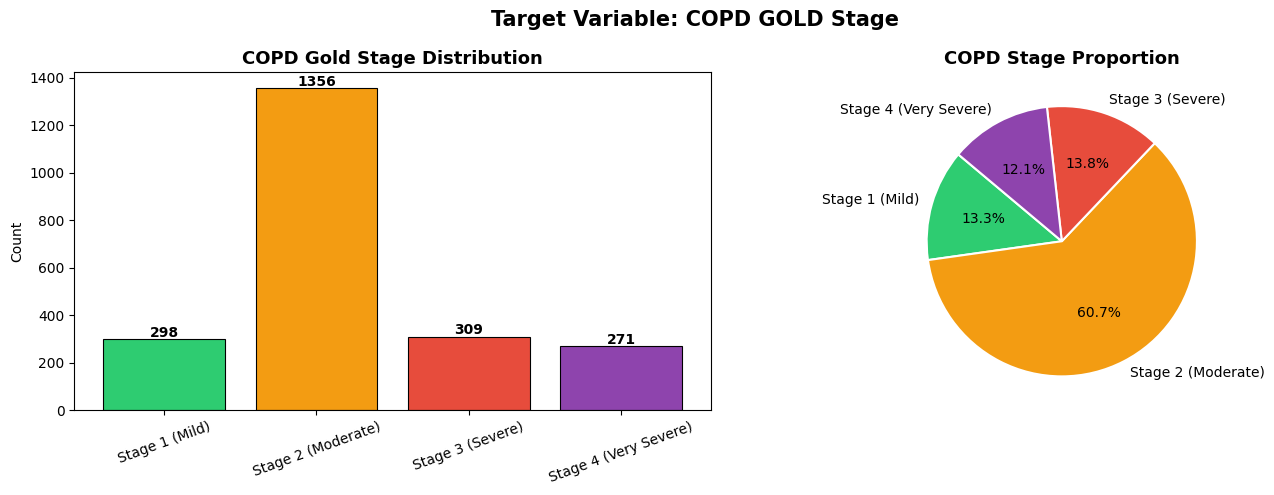

In [7]:
# Cell 7: Visualize class distribution
labels = ['Stage 1 (Mild)', 'Stage 2 (Moderate)', 'Stage 3 (Severe)', 'Stage 4 (Very Severe)']
counts = df_proc['target'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
axes[0].bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('COPD Gold Stage Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('COPD Stage Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: COPD GOLD Stage', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('copd_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

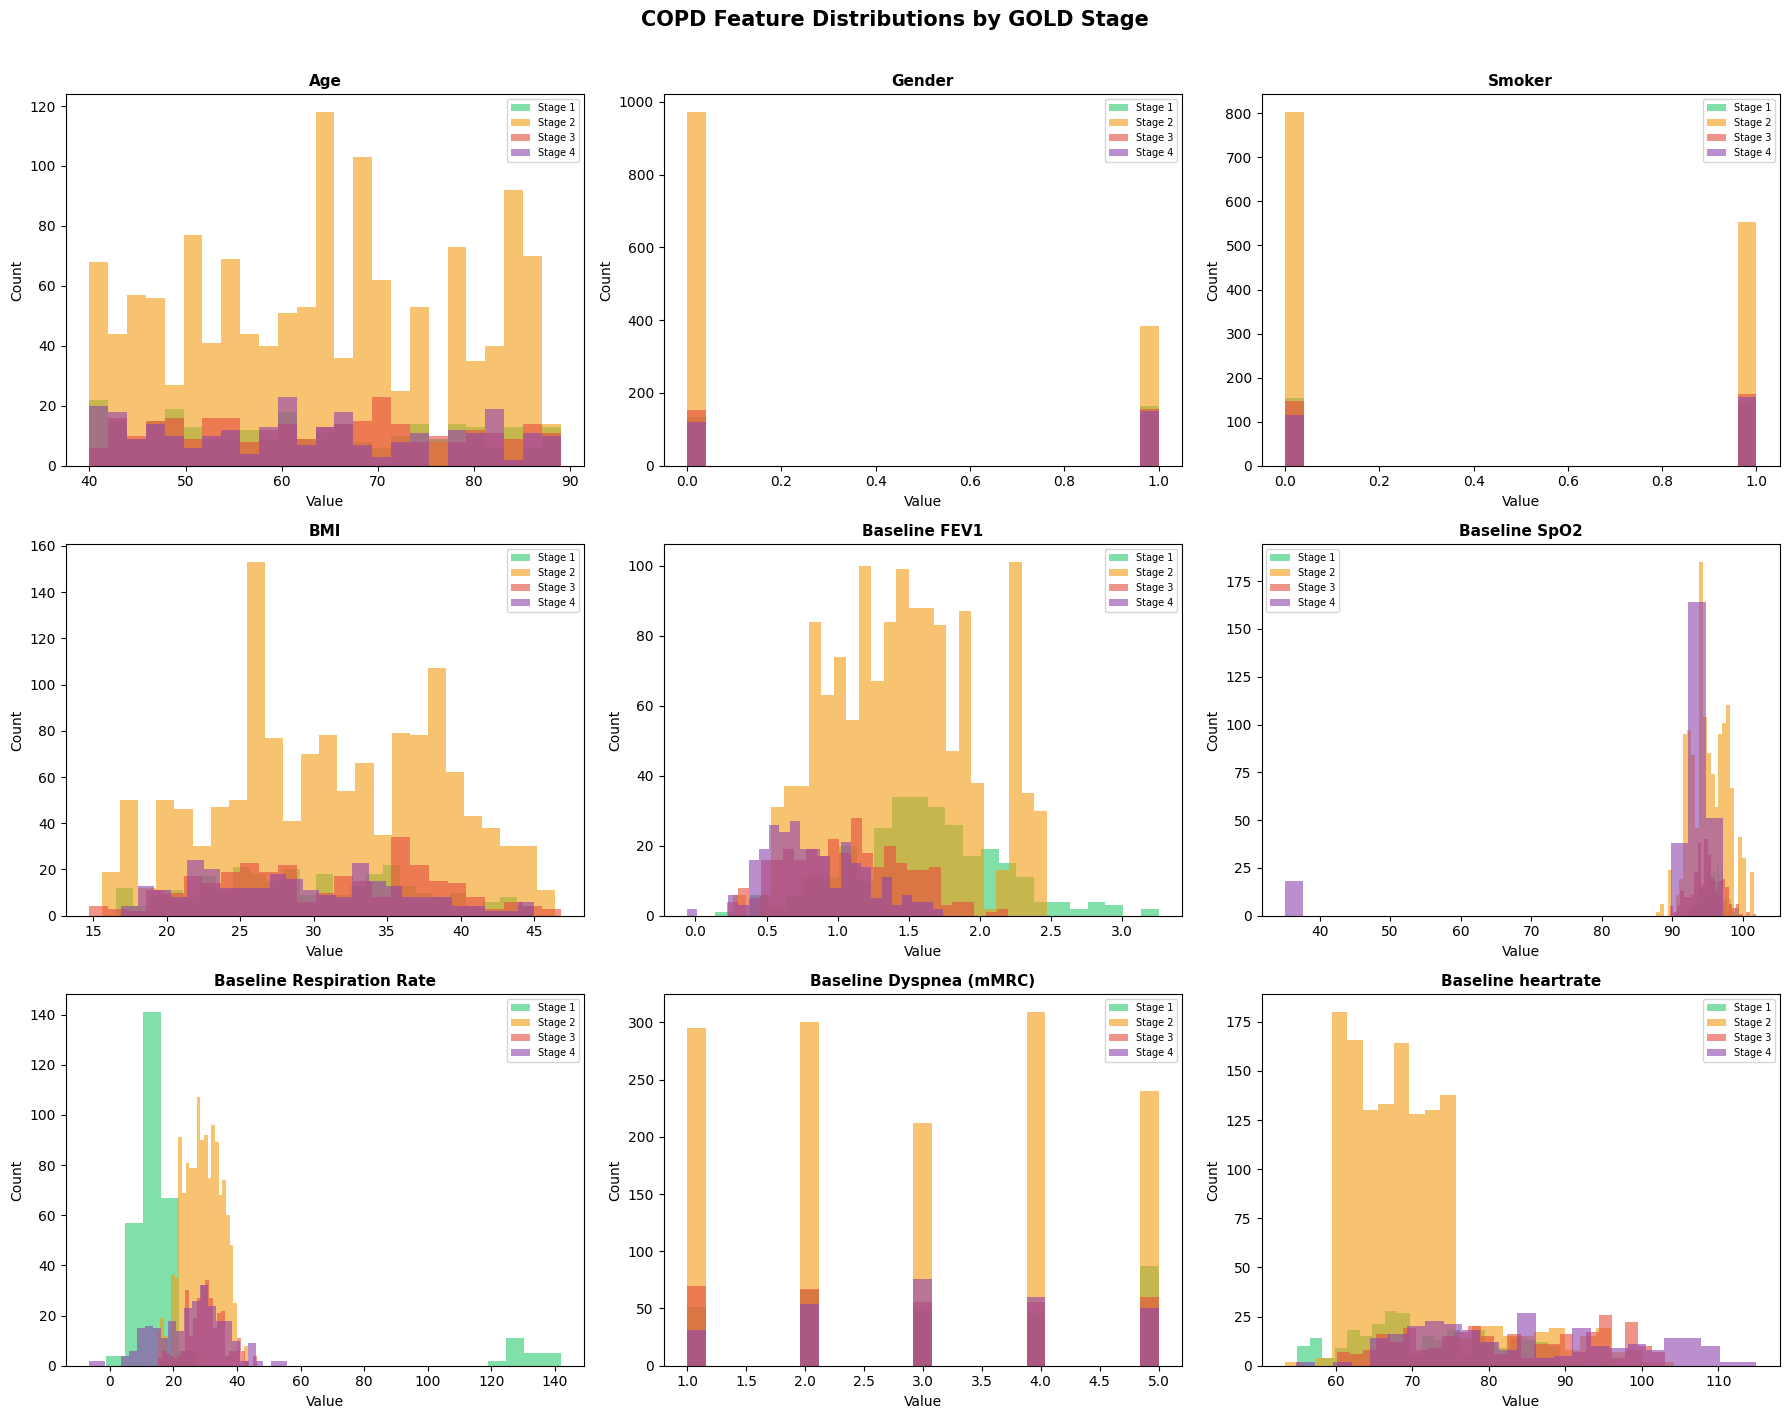

In [8]:
# Cell 8: Feature distributions by COPD stage
feature_cols = [c for c in df_proc.columns if c != 'target']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
stage_labels = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
palette = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

for i, col in enumerate(feature_cols):
    for j, stage in enumerate([0, 1, 2, 3]):
        data = df_proc[df_proc['target'] == stage][col]
        axes[i].hist(data, bins=25, alpha=0.6, color=palette[j],
                     label=stage_labels[j], edgecolor='none')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=7)

plt.suptitle('COPD Feature Distributions by GOLD Stage', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('copd_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

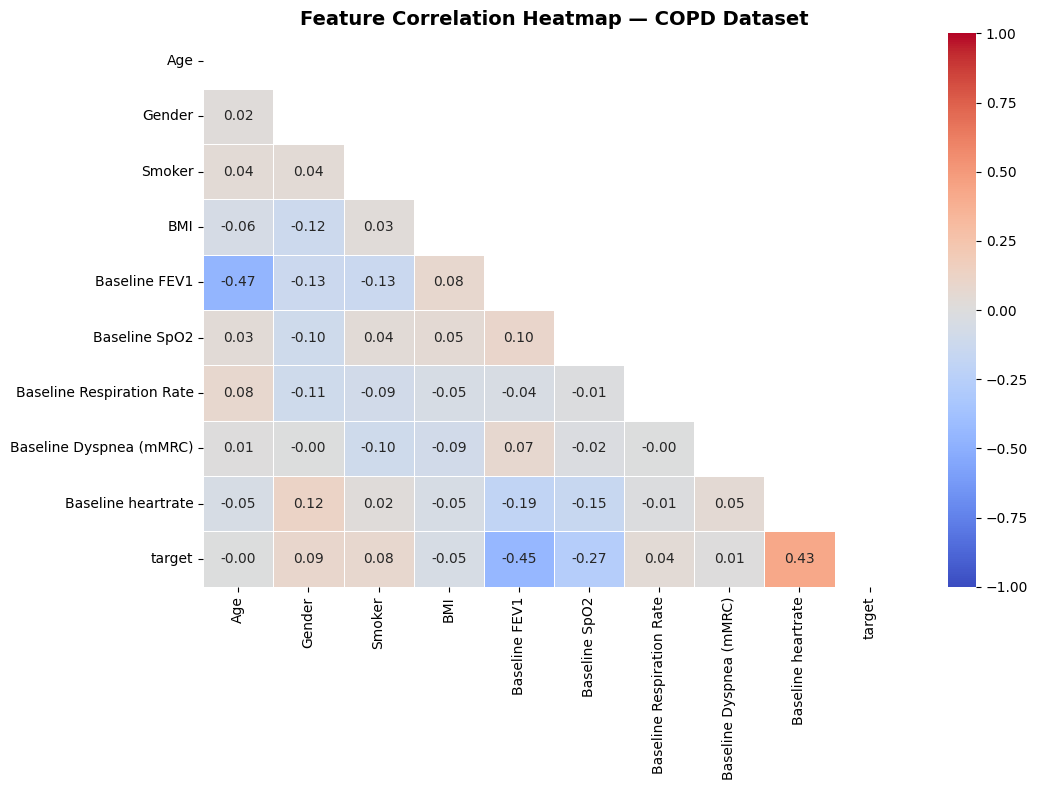

In [9]:
# Cell 9: Correlation heatmap
plt.figure(figsize=(11, 8))
corr = df_proc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={"size": 10}, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap — COPD Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('copd_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

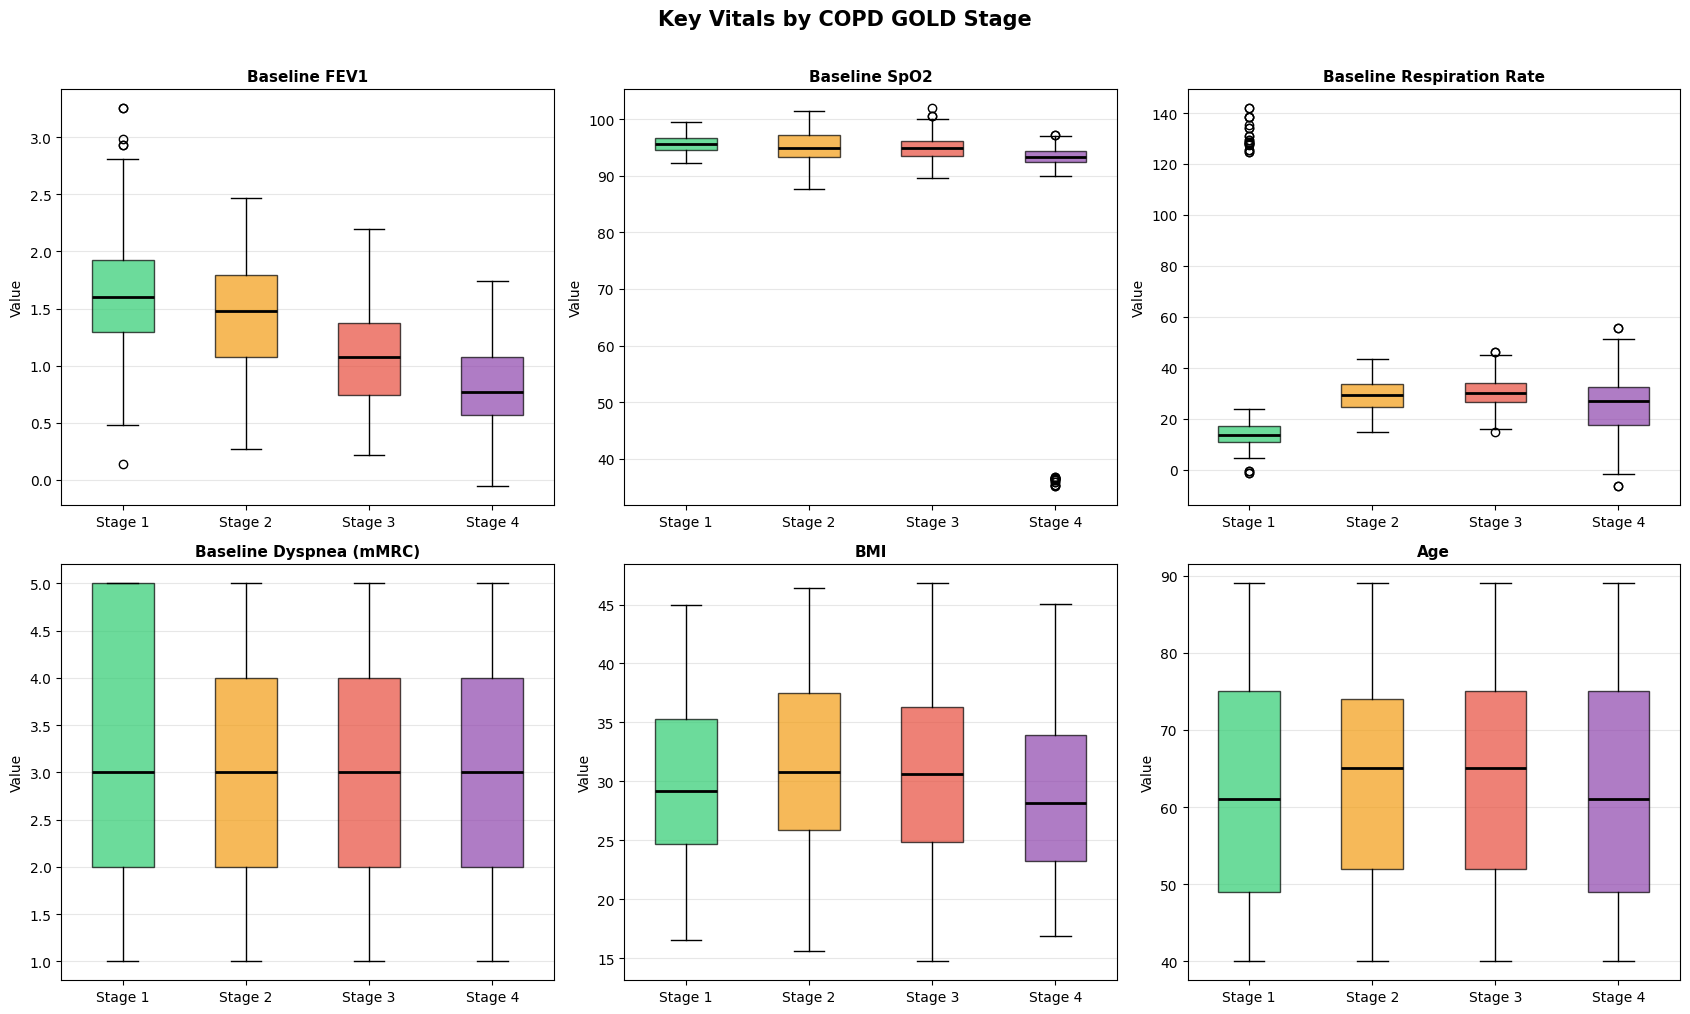

In [10]:
# Cell 10: Boxplots of key vitals by COPD stage
key_features = ['Baseline FEV1', 'Baseline SpO2', 'Baseline Respiration Rate',
                 'Baseline Dyspnea (mMRC)', 'BMI', 'Age']

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()
palette = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c', 3: '#8e44ad'}

for i, col in enumerate(key_features):
    for stage in [0, 1, 2, 3]:
        vals = df_proc[df_proc['target'] == stage][col].dropna()
        bp = axes[i].boxplot(vals, positions=[stage], widths=0.5,
                              patch_artist=True,
                              boxprops=dict(facecolor=palette[stage], alpha=0.7),
                              medianprops=dict(color='black', linewidth=2))
    axes[i].set_xticks([0, 1, 2, 3])
    axes[i].set_xticklabels(['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4'])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Key Vitals by COPD GOLD Stage', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('copd_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Cell 11: Split and scale
X = df_proc.drop('target', axis=1)
y = df_proc['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"✅ Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Feature names: {X.columns.tolist()}")
print(f"\nTrain class dist: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test  class dist: {dict(zip(*np.unique(y_test,  return_counts=True)))}")

✅ Train: (1787, 9) | Test: (447, 9)
Feature names: ['Age', 'Gender', 'Smoker', 'BMI', 'Baseline FEV1', 'Baseline SpO2', 'Baseline Respiration Rate', 'Baseline Dyspnea (mMRC)', 'Baseline heartrate']

Train class dist: {0: 238, 1: 1085, 2: 247, 3: 217}
Test  class dist: {0: 60, 1: 271, 2: 62, 3: 54}


In [12]:
# Cell 12: Define all 11 ML algorithms
models = {
    'Logistic Regression':   LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree':         DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Extra Trees':           ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost':              AdaBoostClassifier(n_estimators=200, random_state=42),
    'XGBoost':               XGBClassifier(n_estimators=200, eval_metric='mlogloss',
                                            use_label_encoder=False, random_state=42),
    'LightGBM':              LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
    'SVM (RBF)':             SVC(kernel='rbf', probability=True, random_state=42),
    'K-Nearest Neighbors':   KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes':           GaussianNB(),
}

# Models needing scaled input
SCALED_MODELS = {'Logistic Regression', 'SVM (RBF)', 'K-Nearest Neighbors'}

print(f"✅ {len(models)} algorithms ready:")
for name in models:
    print(f"   {'🔷' if name in SCALED_MODELS else '🔶'} {name}")
print("\n🔷 = uses scaled data | 🔶 = uses raw data")

✅ 11 algorithms ready:
   🔷 Logistic Regression
   🔶 Decision Tree
   🔶 Random Forest
   🔶 Extra Trees
   🔶 Gradient Boosting
   🔶 AdaBoost
   🔶 XGBoost
   🔶 LightGBM
   🔷 SVM (RBF)
   🔷 K-Nearest Neighbors
   🔶 Naive Bayes

🔷 = uses scaled data | 🔶 = uses raw data


In [13]:
# Cell 13: Train all models and evaluate

results = {}

print(f"{'Model':<25} {'Accuracy':>10} {'AUC-OvR':>10} {'CV Mean':>10} {'CV Std':>8}")
print("=" * 68)

for name, model in models.items():
    Xtr = X_train_sc if name in SCALED_MODELS else X_train.values
    Xte = X_test_sc  if name in SCALED_MODELS else X_test.values

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte) if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro') if y_prob is not None else None
    cv  = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy', n_jobs=-1)

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': acc, 'auc': auc, 'cv_mean': cv.mean(), 'cv_std': cv.std()
    }
    auc_str = f"{auc:.4f}" if auc else "  N/A  "
    print(f"{name:<25} {acc:>10.4f} {auc_str:>10} {cv.mean():>10.4f} {cv.std():>8.4f}")

print("\n✅ All models trained!")

Model                       Accuracy    AUC-OvR    CV Mean   CV Std


Logistic Regression           0.7136     0.8574     0.7174   0.0184


Decision Tree                 0.8322     0.9034     0.8383   0.0123


Random Forest                 0.9530     0.9953     0.9233   0.0045


Extra Trees                   0.9530     0.9968     0.9273   0.0030


Gradient Boosting             0.9441     0.9909     0.9289   0.0109


AdaBoost                      0.6510     0.8751     0.6402   0.0242


XGBoost                       0.9597     0.9949     0.9289   0.0093


LightGBM                      0.9575     0.9982     0.9317   0.0104


SVM (RBF)                     0.8166     0.9476     0.8293   0.0219
K-Nearest Neighbors           0.7875     0.9176     0.7756   0.0103
Naive Bayes                   0.7405     0.8911     0.7504   0.0233

✅ All models trained!


In [14]:
# Cell 14: Ranked summary table
summary = pd.DataFrame([{
    'Model':      name,
    'Accuracy':   r['accuracy'],
    'AUC (OvR)':  r['auc'] if r['auc'] else np.nan,
    'CV Mean':    r['cv_mean'],
    'CV Std':     r['cv_std'],
} for name, r in results.items()]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

summary.index += 1
print("🏆 Model Ranking:\n")
print(summary.to_string())
print(f"\n🥇 Best Model: {summary.iloc[0]['Model']} — Accuracy: {summary.iloc[0]['Accuracy']:.4f}")

🏆 Model Ranking:

                  Model  Accuracy  AUC (OvR)   CV Mean    CV Std
1               XGBoost  0.959732   0.994927  0.928934  0.009261
2              LightGBM  0.957494   0.998204  0.931728  0.010426
3         Random Forest  0.953020   0.995284  0.923335  0.004547
4           Extra Trees  0.953020   0.996801  0.927254  0.003031
5     Gradient Boosting  0.944072   0.990884  0.928920  0.010920
6         Decision Tree  0.832215   0.903427  0.838285  0.012330
7             SVM (RBF)  0.816555   0.947597  0.829334  0.021924
8   K-Nearest Neighbors  0.787472   0.917595  0.775597  0.010320
9           Naive Bayes  0.740492   0.891122  0.750422  0.023326
10  Logistic Regression  0.713647   0.857417  0.717417  0.018418
11             AdaBoost  0.651007   0.875136  0.640155  0.024196

🥇 Best Model: XGBoost — Accuracy: 0.9597


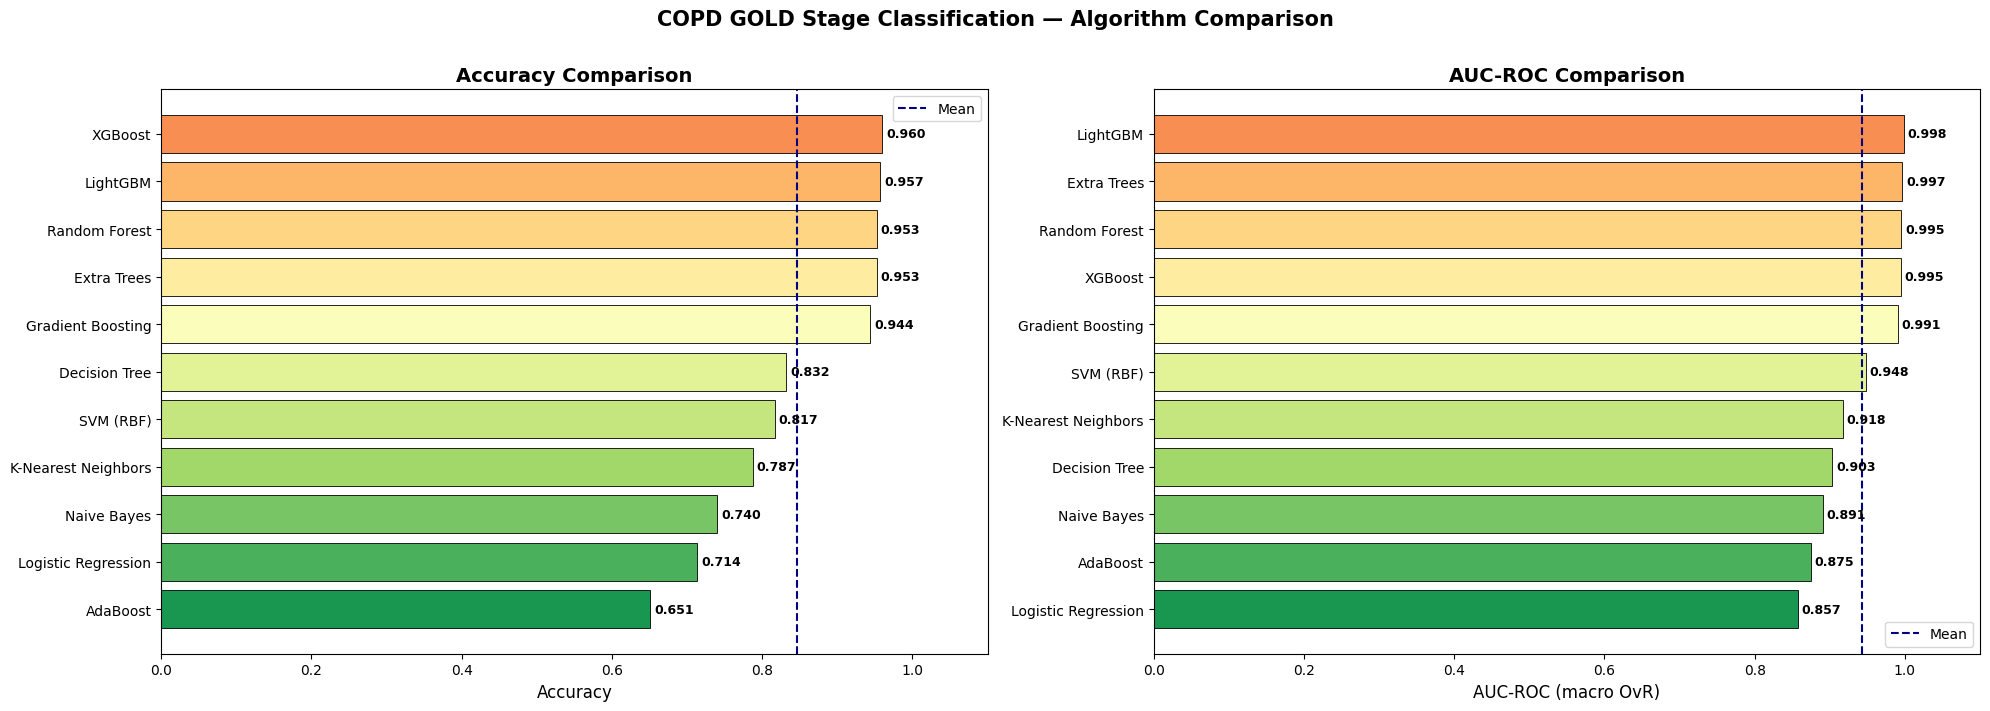

✅ Saved: copd_algorithm_comparison.png


In [15]:
# Cell 15: Side-by-side accuracy and AUC comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
cmap = plt.cm.RdYlGn(np.linspace(0.25, 0.9, len(summary)))

# Accuracy
bars = axes[0].barh(summary['Model'], summary['Accuracy'], color=cmap, edgecolor='black', linewidth=0.6)
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 1.1)
axes[0].axvline(summary['Accuracy'].mean(), color='navy', linestyle='--', lw=1.5, label='Mean')
for bar, val in zip(bars, summary['Accuracy']):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
axes[0].legend()
axes[0].invert_yaxis()

# AUC
auc_df = summary.dropna(subset=['AUC (OvR)']).sort_values('AUC (OvR)', ascending=False)
cmap2 = plt.cm.RdYlGn(np.linspace(0.25, 0.9, len(auc_df)))
bars2 = axes[1].barh(auc_df['Model'], auc_df['AUC (OvR)'], color=cmap2, edgecolor='black', linewidth=0.6)
axes[1].set_xlabel('AUC-ROC (macro OvR)', fontsize=12)
axes[1].set_title('AUC-ROC Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 1.1)
axes[1].axvline(auc_df['AUC (OvR)'].mean(), color='navy', linestyle='--', lw=1.5, label='Mean')
for bar, val in zip(bars2, auc_df['AUC (OvR)']):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
axes[1].legend()
axes[1].invert_yaxis()

plt.suptitle('COPD GOLD Stage Classification — Algorithm Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('copd_algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: copd_algorithm_comparison.png")

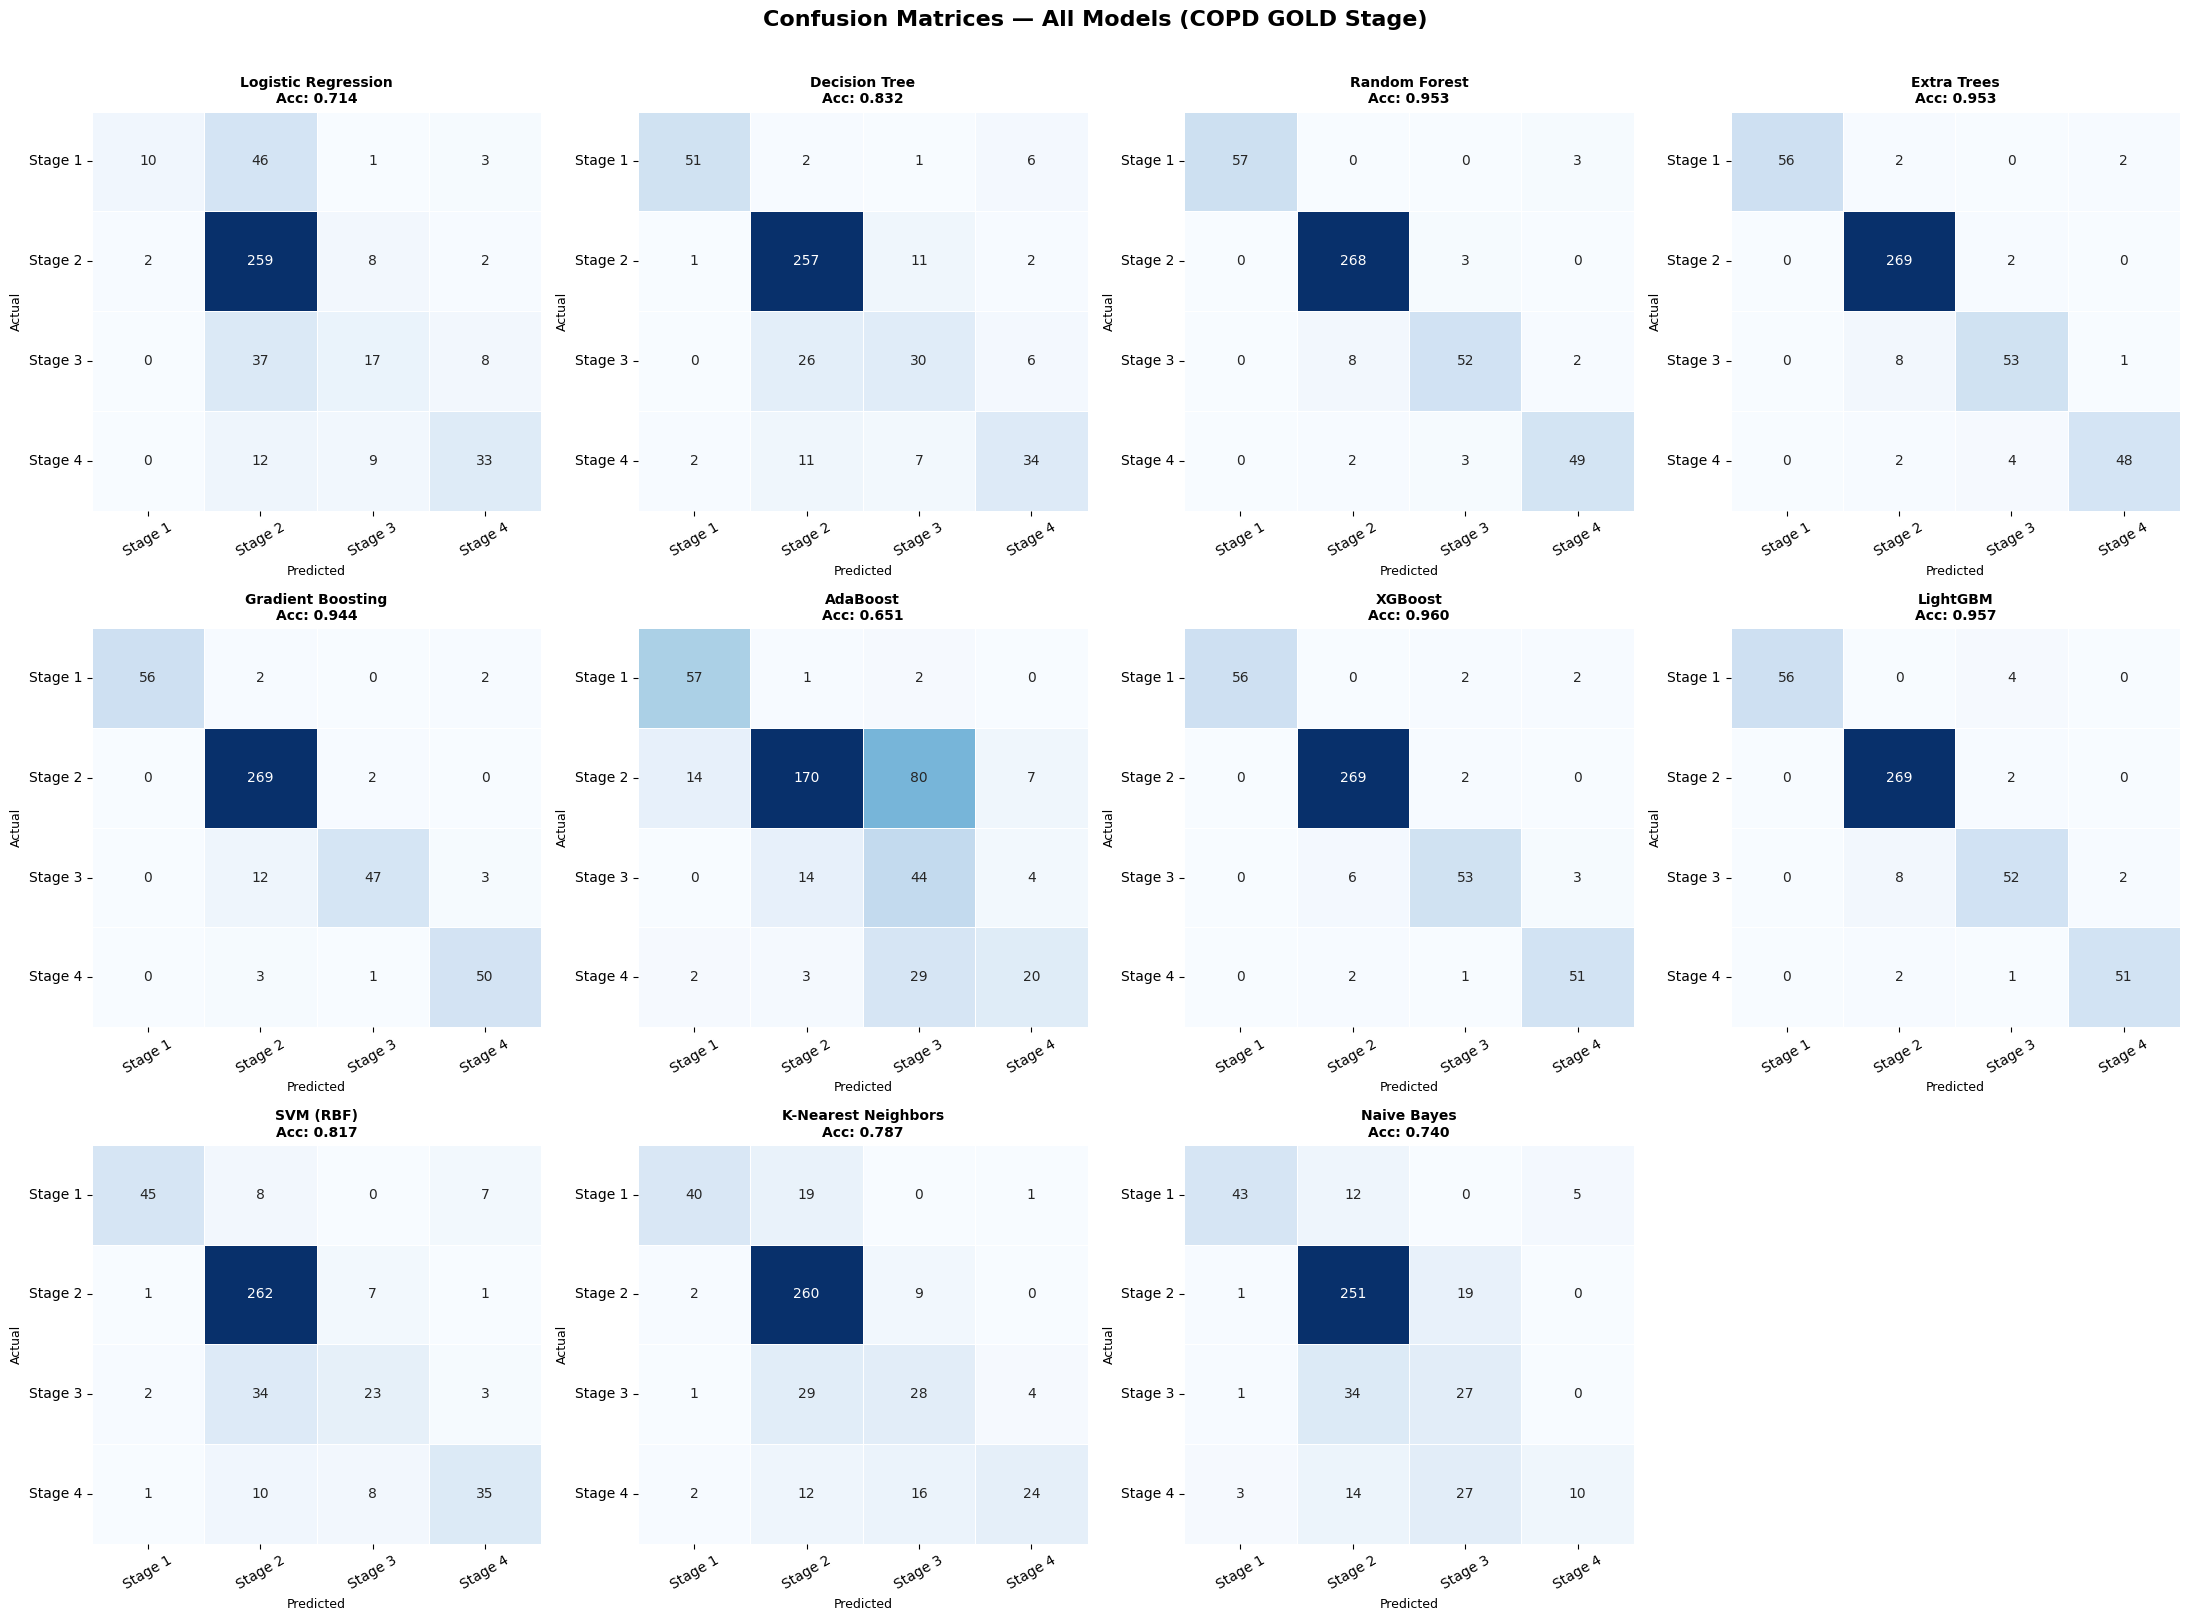

✅ Saved: copd_confusion_matrices.png


In [16]:
# Cell 16: Confusion matrices for all 11 models
stage_names = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']

fig, axes = plt.subplots(3, 4, figsize=(22, 16))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=stage_names, yticklabels=stage_names,
                linewidths=0.5, cbar=False)
    acc = r['accuracy']
    axes[i].set_title(f"{name}\nAcc: {acc:.3f}", fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=9)
    axes[i].set_ylabel('Actual', fontsize=9)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].tick_params(axis='y', rotation=0)

# Hide unused subplots
for j in range(len(results), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models (COPD GOLD Stage)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('copd_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: copd_confusion_matrices.png")

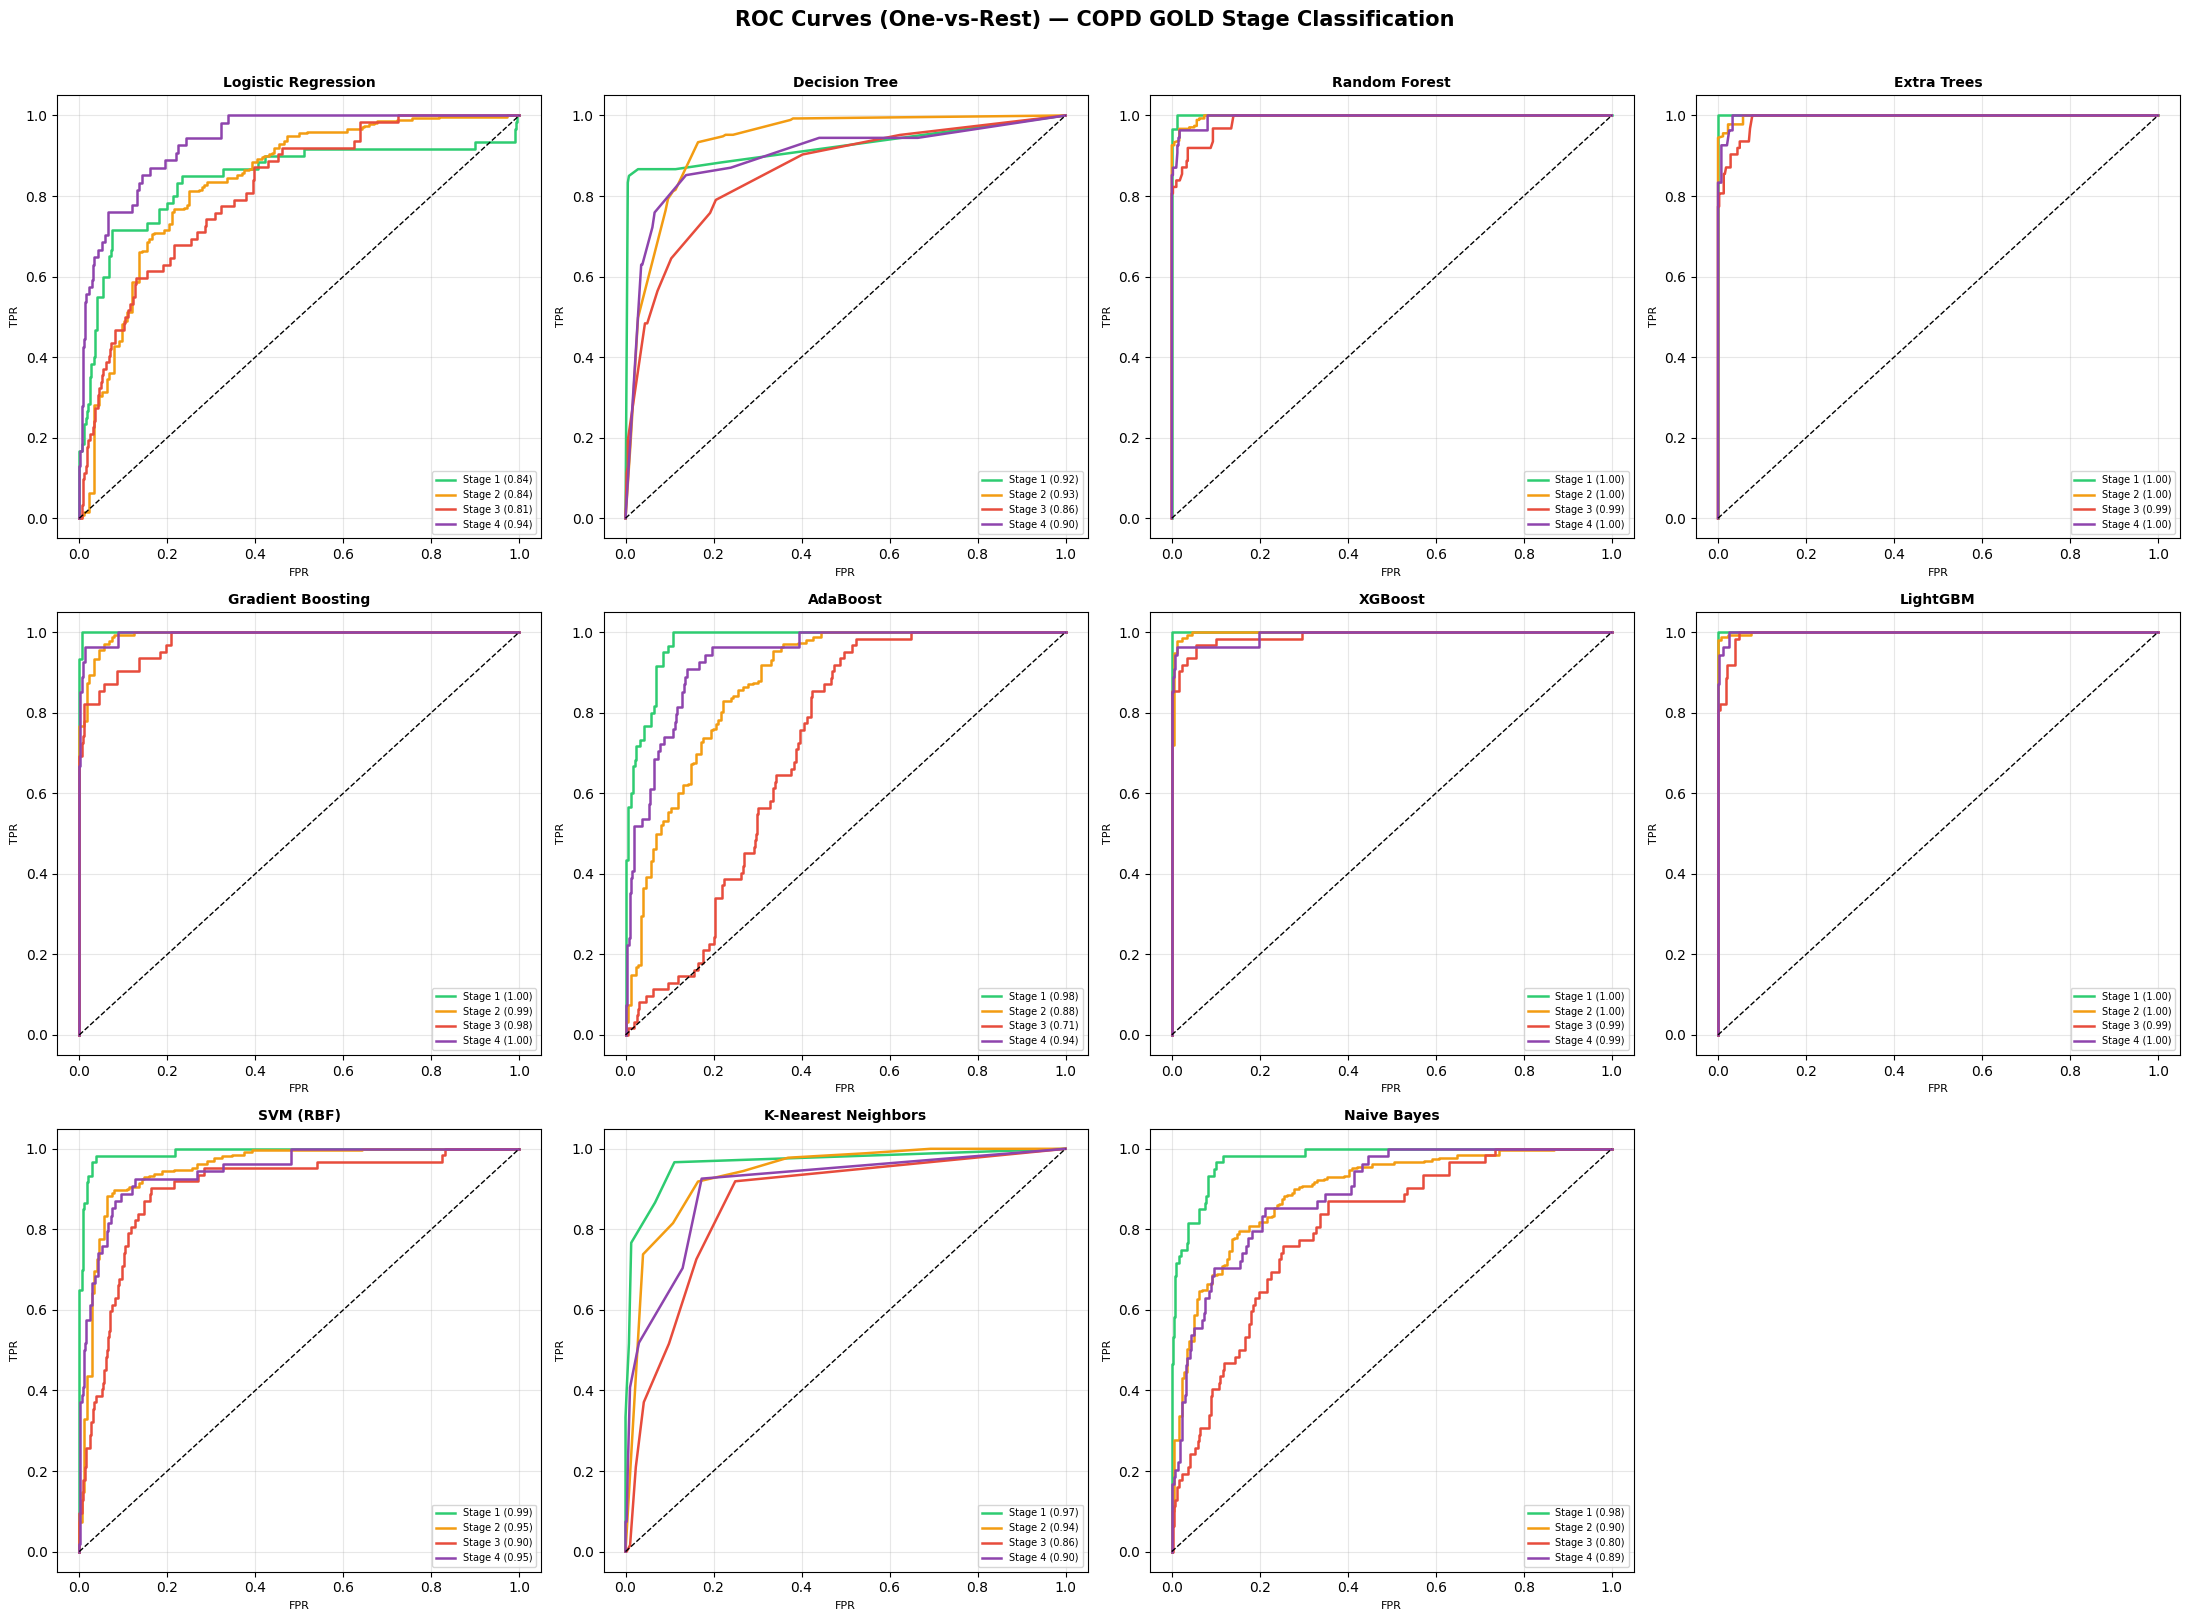

✅ Saved: copd_roc_curves.png


In [17]:
# Cell 17: ROC curves per GOLD stage for all models (OvR strategy)
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
stage_names = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
colors_stage = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

fig, axes = plt.subplots(3, 4, figsize=(22, 16))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    if r['y_prob'] is None:
        axes[i].text(0.5, 0.5, 'No Probability\nEstimate',
                     ha='center', va='center', fontsize=11)
        axes[i].set_title(name, fontsize=10, fontweight='bold')
        continue
    for k, (sname, sc) in enumerate(zip(stage_names, colors_stage)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, k], r['y_prob'][:, k])
        auc_k = roc_auc_score(y_test_bin[:, k], r['y_prob'][:, k])
        axes[i].plot(fpr, tpr, color=sc, lw=1.8, label=f'{sname} ({auc_k:.2f})')
    axes[i].plot([0,1],[0,1],'k--',lw=1)
    axes[i].set_title(f"{name}", fontsize=10, fontweight='bold')
    axes[i].set_xlabel('FPR', fontsize=8)
    axes[i].set_ylabel('TPR', fontsize=8)
    axes[i].legend(fontsize=7, loc='lower right')
    axes[i].grid(alpha=0.3)

for j in range(len(results), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ROC Curves (One-vs-Rest) — COPD GOLD Stage Classification', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('copd_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: copd_roc_curves.png")

In [18]:
# Cell 18: Full classification reports
stage_names = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']

for name, r in results.items():
    print(f"\n{'='*60}")
    print(f"  📋 {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, r['y_pred'],
                                 target_names=stage_names, digits=4))


  📋 Logistic Regression
              precision    recall  f1-score   support

     Stage 1     0.8333    0.1667    0.2778        60
     Stage 2     0.7316    0.9557    0.8288       271
     Stage 3     0.4857    0.2742    0.3505        62
     Stage 4     0.7174    0.6111    0.6600        54

    accuracy                         0.7136       447
   macro avg     0.6920    0.5019    0.5293       447
weighted avg     0.7095    0.7136    0.6681       447


  📋 Decision Tree
              precision    recall  f1-score   support

     Stage 1     0.9444    0.8500    0.8947        60
     Stage 2     0.8682    0.9483    0.9065       271
     Stage 3     0.6122    0.4839    0.5405        62
     Stage 4     0.7083    0.6296    0.6667        54

    accuracy                         0.8322       447
   macro avg     0.7833    0.7280    0.7521       447
weighted avg     0.8236    0.8322    0.8252       447


  📋 Random Forest
              precision    recall  f1-score   support

     Stage 1

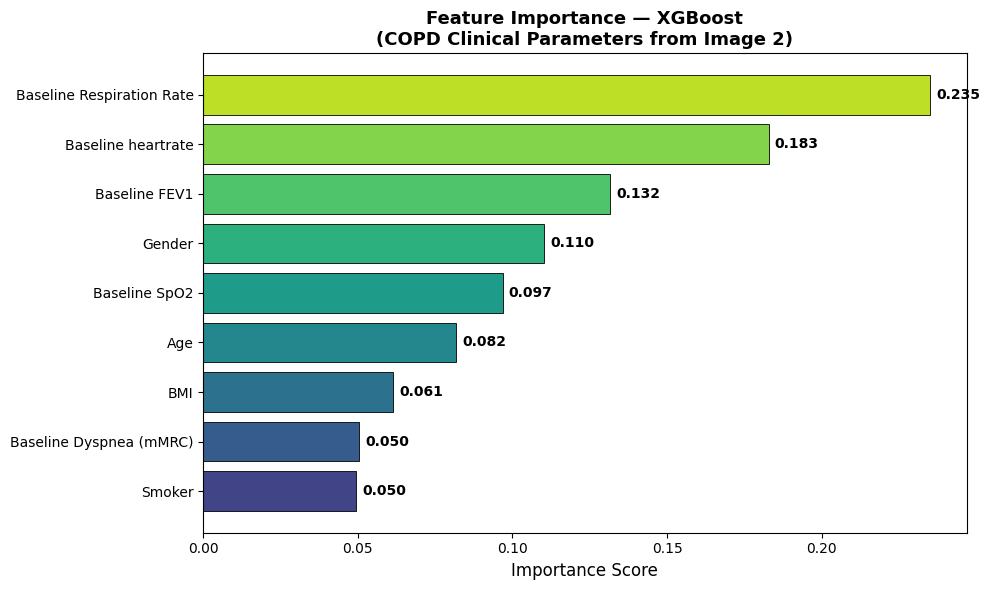

✅ Saved: copd_feature_importance.png | Model: XGBoost


In [19]:
# Cell 19: Feature importance from top tree-based model
tree_models = ['Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM',
               'Gradient Boosting', 'Decision Tree']

feat_model = next((m for m in [summary.iloc[0]['Model']] + tree_models
                    if m in results and hasattr(results[m]['model'], 'feature_importances_')), None)

if feat_model:
    importances = results[feat_model]['model'].feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values()

    plt.figure(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(feat_imp)))
    bars = plt.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='black', linewidth=0.6)
    for bar, val in zip(bars, feat_imp.values):
        plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
    plt.xlabel('Importance Score', fontsize=12)
    plt.title(f'Feature Importance — {feat_model}\n(COPD Clinical Parameters from Image 2)',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('copd_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: copd_feature_importance.png | Model: {feat_model}")

Running 5-fold CV for boxplot...
  Logistic Regression      : 0.7174 ± 0.0184
  Decision Tree            : 0.8383 ± 0.0123


  Random Forest            : 0.9233 ± 0.0045


  Extra Trees              : 0.9273 ± 0.0030


  Gradient Boosting        : 0.9289 ± 0.0109


  AdaBoost                 : 0.6402 ± 0.0242


  XGBoost                  : 0.9289 ± 0.0093


  LightGBM                 : 0.9317 ± 0.0104


  SVM (RBF)                : 0.8293 ± 0.0219
  K-Nearest Neighbors      : 0.7756 ± 0.0103
  Naive Bayes              : 0.7504 ± 0.0233


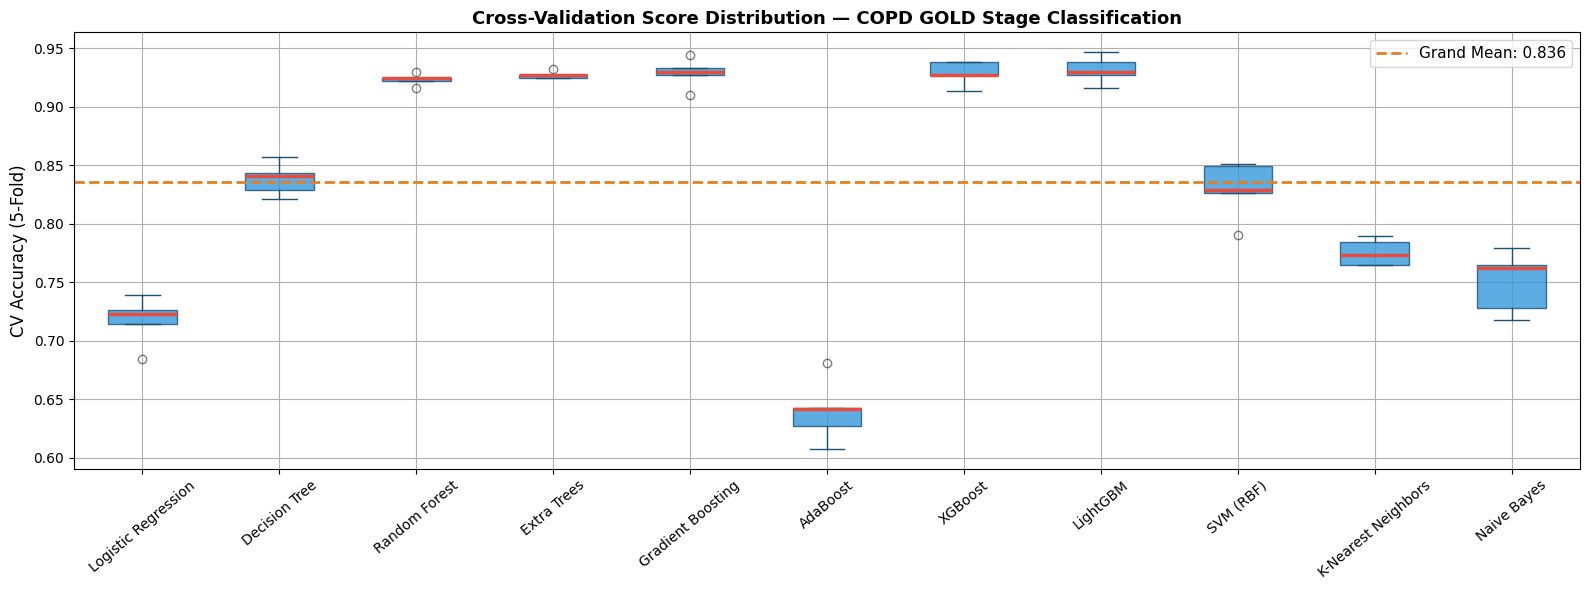

✅ Saved: copd_cv_boxplot.png


In [20]:
# Cell 20: CV score distribution boxplot across all models
cv_data = {}
print("Running 5-fold CV for boxplot...")
for name, model in models.items():
    Xtr = X_train_sc if name in SCALED_MODELS else X_train.values
    scores = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    cv_data[name] = scores
    print(f"  {name:<25}: {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_data)

plt.figure(figsize=(16, 6))
bp = cv_df.boxplot(rot=40, grid=True, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', color='#1a5276', alpha=0.8),
                    medianprops=dict(color='#e74c3c', linewidth=2.5),
                    whiskerprops=dict(color='#1a5276'),
                    capprops=dict(color='#1a5276'),
                    flierprops=dict(marker='o', color='gray', alpha=0.5))
plt.axhline(cv_df.mean().mean(), color='#e67e22', linestyle='--', lw=2, label=f"Grand Mean: {cv_df.mean().mean():.3f}")
plt.ylabel('CV Accuracy (5-Fold)', fontsize=12)
plt.title('Cross-Validation Score Distribution — COPD GOLD Stage Classification', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('copd_cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: copd_cv_boxplot.png")

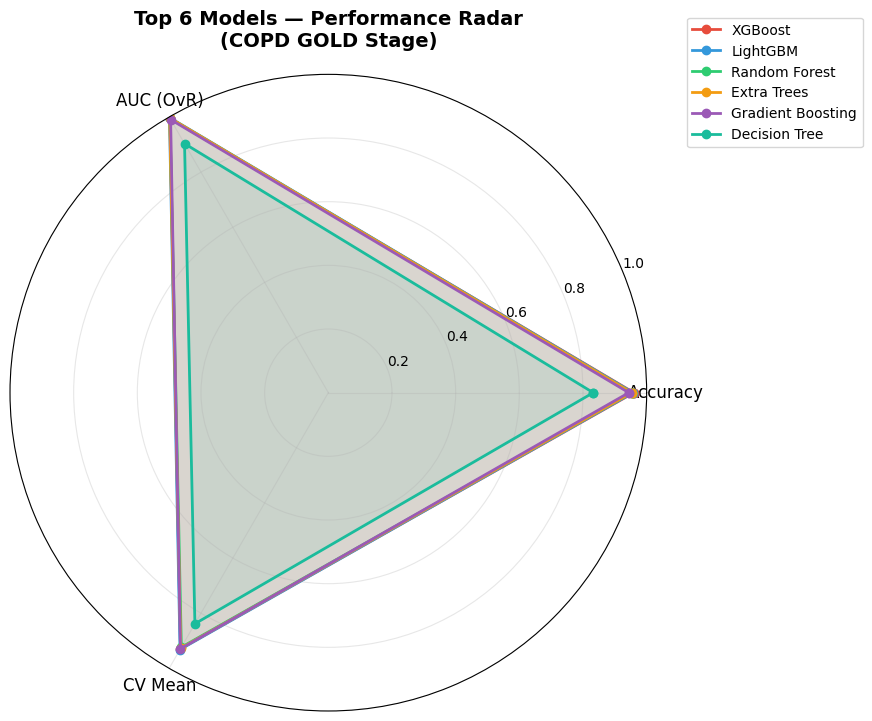

✅ Saved: copd_radar_chart.png


In [21]:
# Cell 21: Radar chart comparing top 6 models
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

top6 = summary.head(6)['Model'].tolist()
metrics_radar = ['Accuracy', 'AUC (OvR)', 'CV Mean']

values = []
for name in top6:
    r = results[name]
    values.append([
        r['accuracy'],
        r['auc'] if r['auc'] else 0,
        r['cv_mean']
    ])

angles = np.linspace(0, 2 * np.pi, len(metrics_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors_r = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']

for i, (name, vals) in enumerate(zip(top6, values)):
    v = vals + vals[:1]
    ax.plot(angles, v, 'o-', linewidth=2, color=colors_r[i], label=name)
    ax.fill(angles, v, alpha=0.08, color=colors_r[i])

ax.set_thetagrids(np.degrees(angles[:-1]), metrics_radar, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Top 6 Models — Performance Radar\n(COPD GOLD Stage)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('copd_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: copd_radar_chart.png")

In [22]:
# Cell 22: Final printed summary
print("=" * 65)
print("       COPD GOLD STAGE CLASSIFICATION — FINAL RESULTS")
print("=" * 65)
print(summary.to_string())
print()
print(f" Best:  {summary.iloc[0]['Model']:<25} Acc={summary.iloc[0]['Accuracy']:.4f}")
print(f" 2nd:   {summary.iloc[1]['Model']:<25} Acc={summary.iloc[1]['Accuracy']:.4f}")
print(f" 3rd:   {summary.iloc[2]['Model']:<25} Acc={summary.iloc[2]['Accuracy']:.4f}")
print()
files_saved = [
    'copd_class_distribution.png',
    'copd_feature_distributions.png',
    'copd_correlation.png',
    'copd_boxplots.png',
    'copd_algorithm_comparison.png',
    'copd_confusion_matrices.png',
    'copd_roc_curves.png',
    'copd_feature_importance.png',
    'copd_cv_boxplot.png',
    'copd_radar_chart.png',
]

       COPD GOLD STAGE CLASSIFICATION — FINAL RESULTS
                  Model  Accuracy  AUC (OvR)   CV Mean    CV Std
1               XGBoost  0.959732   0.994927  0.928934  0.009261
2              LightGBM  0.957494   0.998204  0.931728  0.010426
3         Random Forest  0.953020   0.995284  0.923335  0.004547
4           Extra Trees  0.953020   0.996801  0.927254  0.003031
5     Gradient Boosting  0.944072   0.990884  0.928920  0.010920
6         Decision Tree  0.832215   0.903427  0.838285  0.012330
7             SVM (RBF)  0.816555   0.947597  0.829334  0.021924
8   K-Nearest Neighbors  0.787472   0.917595  0.775597  0.010320
9           Naive Bayes  0.740492   0.891122  0.750422  0.023326
10  Logistic Regression  0.713647   0.857417  0.717417  0.018418
11             AdaBoost  0.651007   0.875136  0.640155  0.024196

 Best:  XGBoost                   Acc=0.9597
 2nd:   LightGBM                  Acc=0.9575
 3rd:   Random Forest             Acc=0.9530



In [23]:
# Cell 23: Install CatBoost (not in default Colab)
!pip install catboost -q
from catboost import CatBoostClassifier
print("✅ CatBoost installed and imported!")

✅ CatBoost installed and imported!



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
# Cell 24: Define the 4 models specified by trainer
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

stage_names = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']

four_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=300, eval_metric='mlogloss',
                                          use_label_encoder=False, random_state=42),
    'CatBoost':            CatBoostClassifier(iterations=300, random_seed=42,
                                               verbose=0, auto_class_weights='Balanced'),
}

# LR and SVM use scaled data, tree models use raw
SCALED = {'Logistic Regression'}

print("✅ 4 Models ready:")
for name in four_models:
    print(f"   → {name}")

✅ 4 Models ready:
   → Logistic Regression
   → Random Forest
   → XGBoost
   → CatBoost


In [25]:
# Cell 25: Train all 4 models and collect predictions + probabilities
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
import numpy as np

four_results = {}

print(f"{'Model':<22} {'Accuracy':>10} {'AUC (OvR)':>12} {'CV Mean':>10} {'CV Std':>8}")
print("=" * 65)

for name, model in four_models.items():
    Xtr = X_train_sc if name in SCALED else X_train.values
    Xte = X_test_sc  if name in SCALED else X_test.values

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')

    from sklearn.model_selection import cross_val_score
    cv = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy', n_jobs=-1)

    four_results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_prob':   y_prob,
        'accuracy': acc,
        'auc':      auc,
        'cv_mean':  cv.mean(),
        'cv_std':   cv.std(),
        'cv_scores': cv,
    }
    print(f"{name:<22} {acc:>10.4f} {auc:>12.4f} {cv.mean():>10.4f} {cv.std():>8.4f}")

print("\n✅ All 4 models trained!")

Model                    Accuracy    AUC (OvR)    CV Mean   CV Std
Logistic Regression        0.7136       0.8574     0.7174   0.0184


Random Forest              0.9530       0.9952     0.9205   0.0033


XGBoost                    0.9620       0.9947     0.9284   0.0080


CatBoost                   0.9642       0.9921     0.9345   0.0058

✅ All 4 models trained!


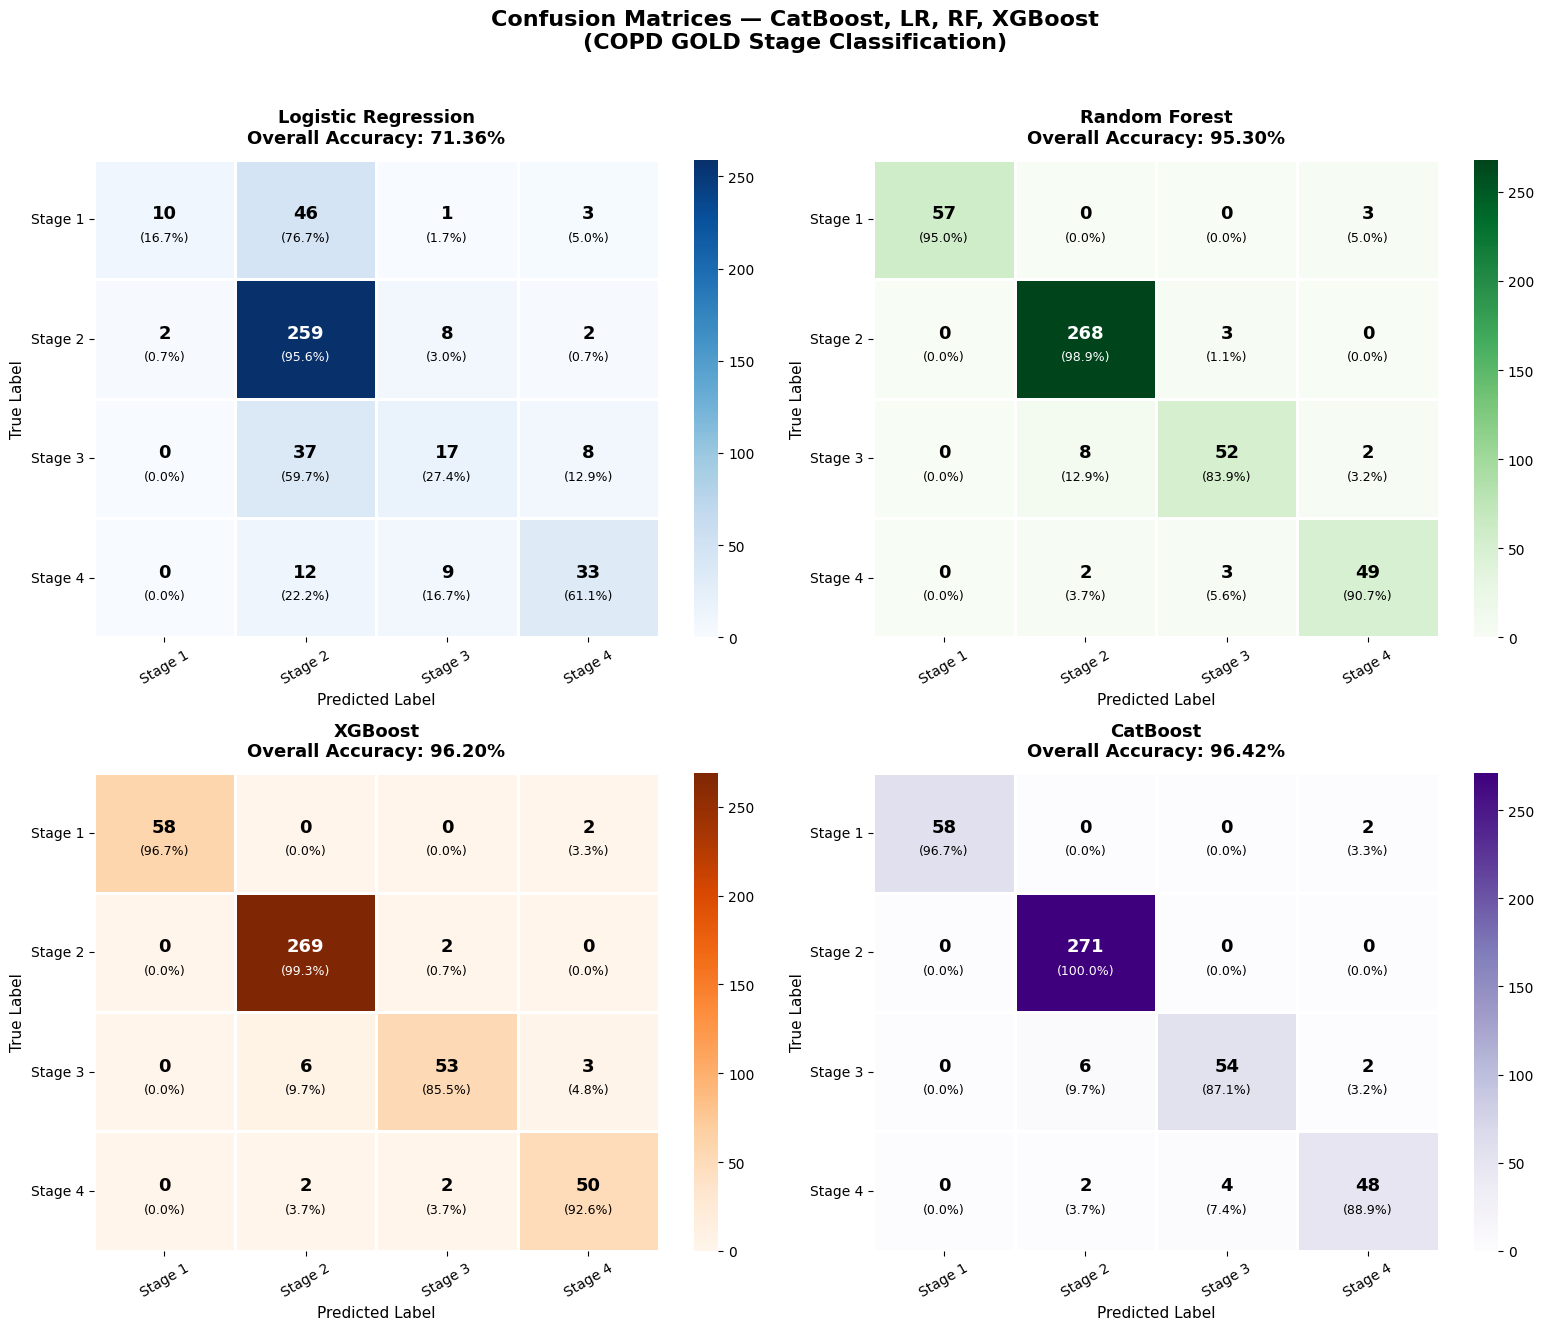

✅ Saved: four_models_confusion_matrices.png


In [26]:
# Cell 26: Confusion matrices for all 4 models — clean 2x2 grid
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()

model_colors = {
    'Logistic Regression': 'Blues',
    'Random Forest':       'Greens',
    'XGBoost':             'Oranges',
    'CatBoost':            'Purples',
}

for i, (name, r) in enumerate(four_results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])

    # Compute per-class accuracy for annotation
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    # Plot raw counts
    sns.heatmap(cm, annot=False, fmt='d', cmap=model_colors[name],
                ax=axes[i], xticklabels=stage_names, yticklabels=stage_names,
                linewidths=0.8, linecolor='white', cbar=True,
                vmin=0, vmax=cm.max())

    # Custom annotation: count + percentage
    for row in range(4):
        for col in range(4):
            count = cm[row, col]
            pct   = cm_pct[row, col]
            color = 'white' if count > cm.max() * 0.6 else 'black'
            axes[i].text(col + 0.5, row + 0.45, str(count),
                         ha='center', va='center', fontsize=13,
                         fontweight='bold', color=color)
            axes[i].text(col + 0.5, row + 0.65, f'({pct:.1f}%)',
                         ha='center', va='center', fontsize=9, color=color)

    axes[i].set_title(f"{name}\nOverall Accuracy: {r['accuracy']*100:.2f}%",
                      fontsize=13, fontweight='bold', pad=12)
    axes[i].set_xlabel('Predicted Label', fontsize=11)
    axes[i].set_ylabel('True Label', fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].tick_params(axis='y', rotation=0)

plt.suptitle('Confusion Matrices — CatBoost, LR, RF, XGBoost\n(COPD GOLD Stage Classification)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('four_models_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: four_models_confusion_matrices.png")

In [27]:
# Cell 27: Full classification report for each model as a styled table
from sklearn.metrics import classification_report
import pandas as pd

all_reports = {}

for name, r in four_results.items():
    report = classification_report(y_test, r['y_pred'],
                                    target_names=stage_names,
                                    output_dict=True)
    df_report = pd.DataFrame(report).T
    df_report = df_report.round(4)
    all_reports[name] = df_report
    print(f"\n{'='*60}")
    print(f"  📋 {name}")
    print(f"{'='*60}")
    print(df_report.to_string())


  📋 Logistic Regression
              precision  recall  f1-score   support
Stage 1          0.8333  0.1667    0.2778   60.0000
Stage 2          0.7316  0.9557    0.8288  271.0000
Stage 3          0.4857  0.2742    0.3505   62.0000
Stage 4          0.7174  0.6111    0.6600   54.0000
accuracy         0.7136  0.7136    0.7136    0.7136
macro avg        0.6920  0.5019    0.5293  447.0000
weighted avg     0.7095  0.7136    0.6681  447.0000

  📋 Random Forest
              precision  recall  f1-score  support
Stage 1          1.0000  0.9500    0.9744   60.000
Stage 2          0.9640  0.9889    0.9763  271.000
Stage 3          0.8966  0.8387    0.8667   62.000
Stage 4          0.9074  0.9074    0.9074   54.000
accuracy         0.9530  0.9530    0.9530    0.953
macro avg        0.9420  0.9213    0.9312  447.000
weighted avg     0.9527  0.9530    0.9525  447.000

  📋 XGBoost
              precision  recall  f1-score  support
Stage 1          1.0000  0.9667    0.9831   60.000
Stage 2          

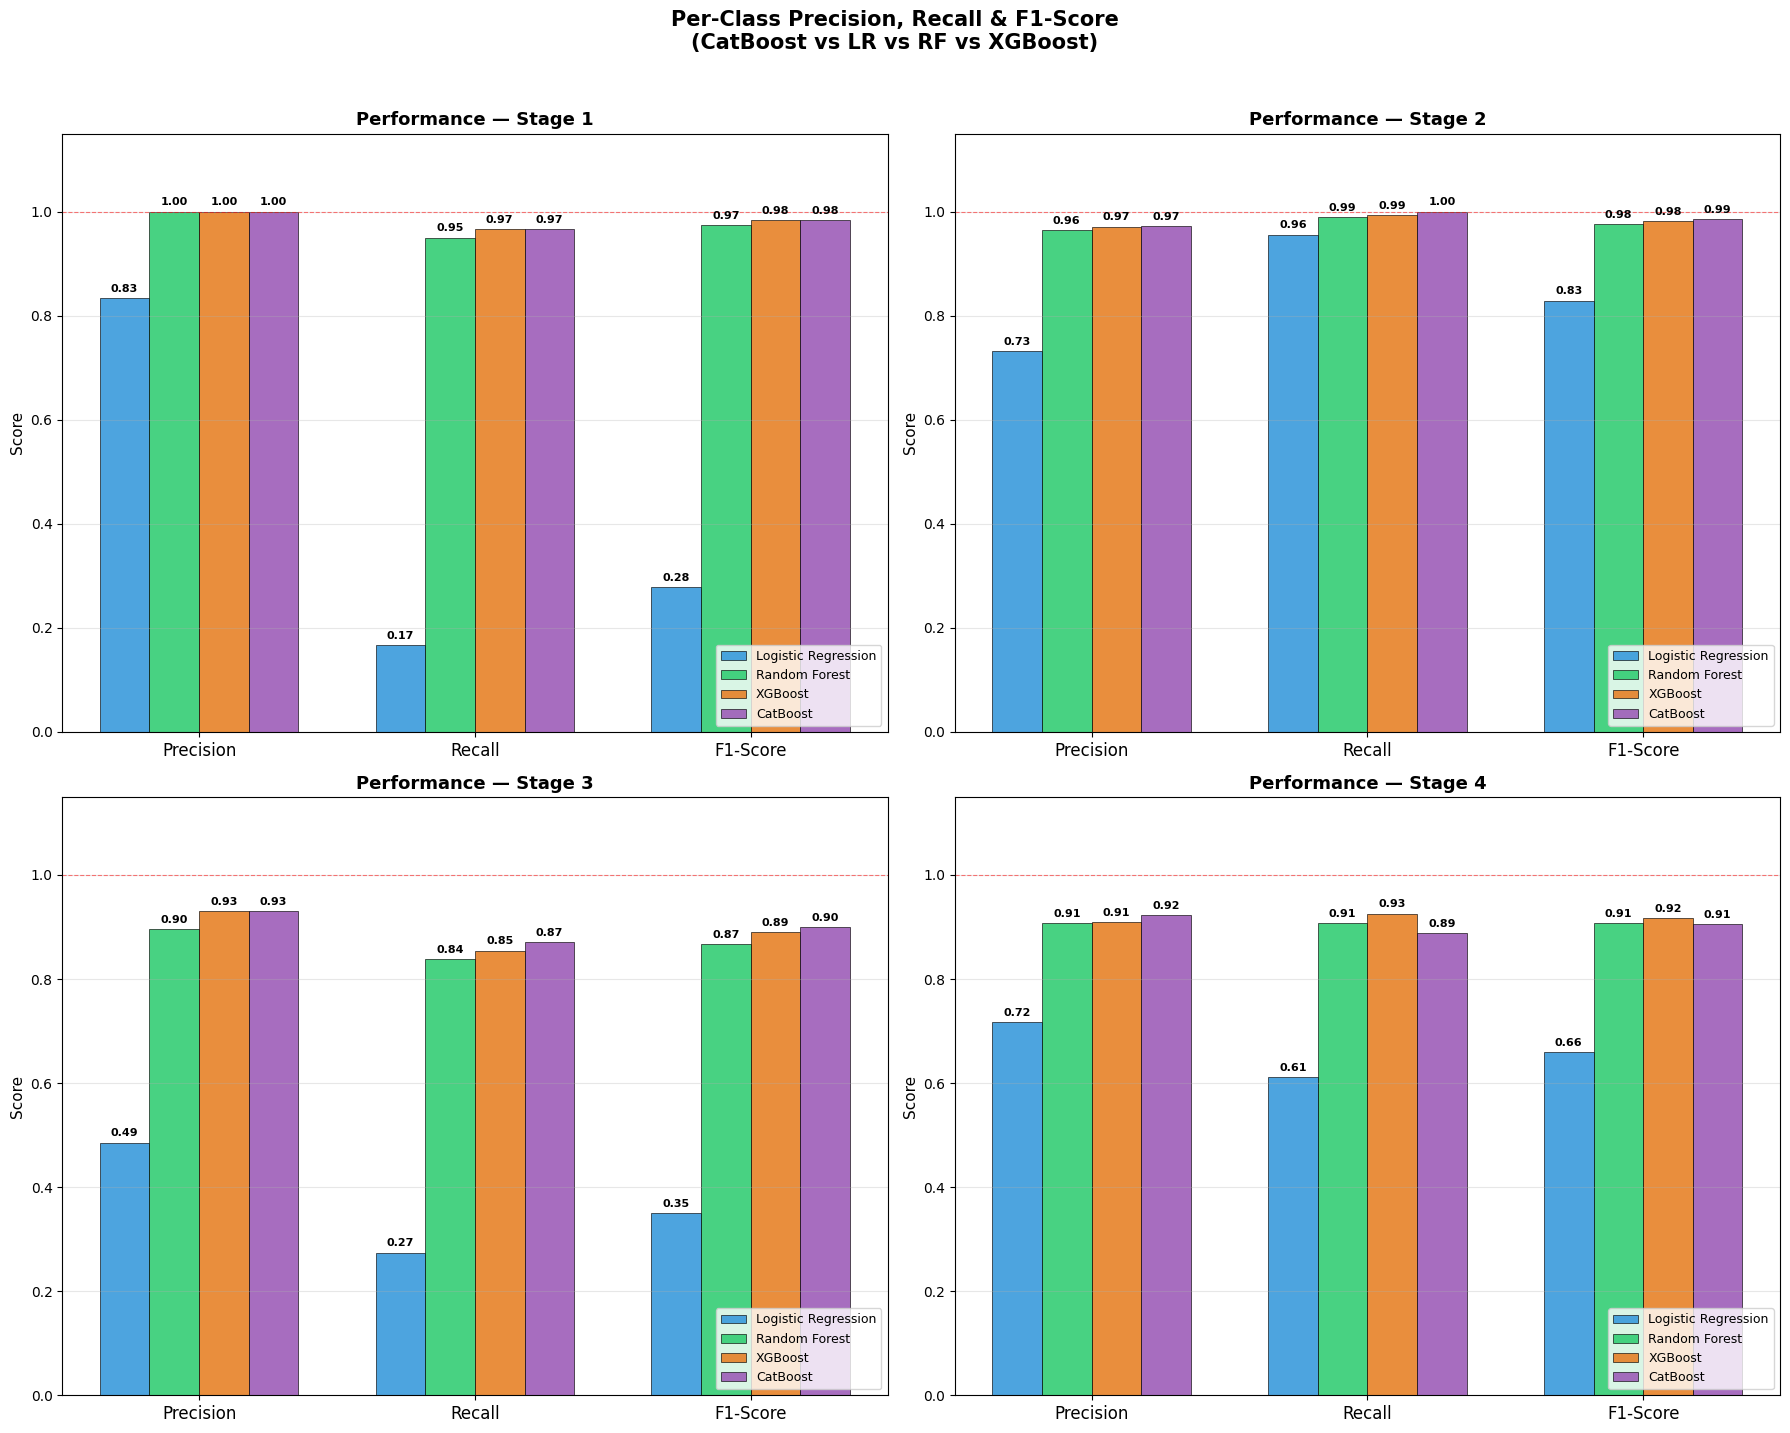

✅ Saved: four_models_performance_by_stage.png


In [28]:
# Cell 28: Per-class Precision, Recall, F1 comparison across 4 models
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

metrics_to_plot = ['precision', 'recall', 'f1-score']
metric_labels   = ['Precision', 'Recall', 'F1-Score']
model_names     = list(four_results.keys())
model_colors    = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for s_idx, stage in enumerate(stage_names):
    ax = axes[s_idx]
    x  = np.arange(len(metrics_to_plot))
    width = 0.18

    for m_idx, (name, r) in enumerate(four_results.items()):
        report = classification_report(y_test, r['y_pred'],
                                        target_names=stage_names,
                                        output_dict=True)
        vals = [report[stage][m] for m in metrics_to_plot]
        bars = ax.bar(x + m_idx * width, vals, width,
                      label=name, color=model_colors[m_idx],
                      edgecolor='black', linewidth=0.5, alpha=0.88)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(metric_labels, fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'Performance — {stage}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(1.0, color='red', linestyle='--', lw=0.8, alpha=0.5)

plt.suptitle('Per-Class Precision, Recall & F1-Score\n(CatBoost vs LR vs RF vs XGBoost)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('four_models_performance_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: four_models_performance_by_stage.png")

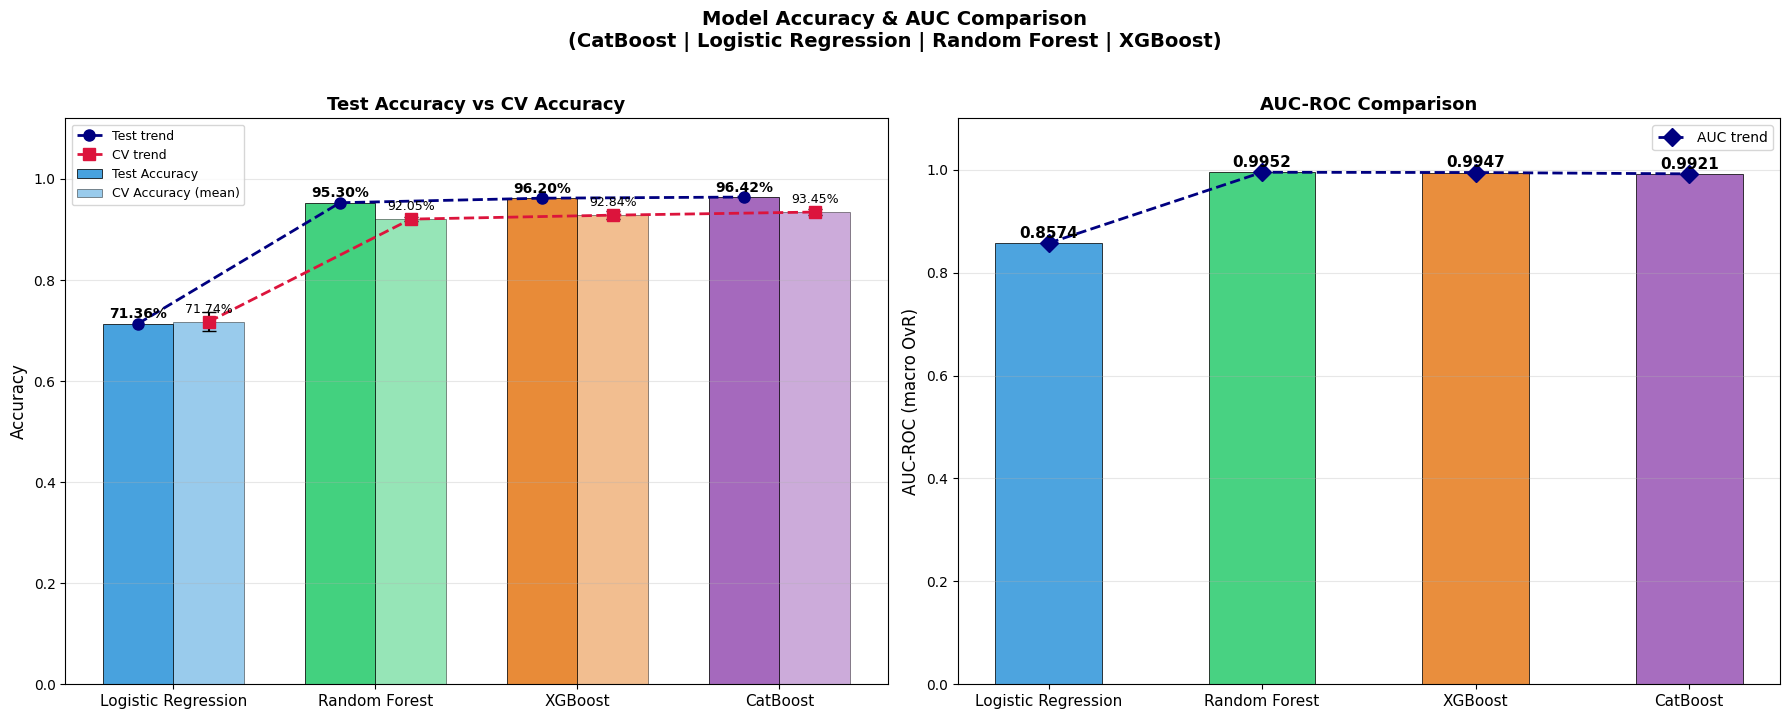

✅ Saved: four_models_accuracy_comparison.png


In [29]:
# Cell 29: Accuracy comparison — grouped bar with CV error bars + trend line
import matplotlib.pyplot as plt
import numpy as np

names      = list(four_results.keys())
accs       = [four_results[n]['accuracy']  for n in names]
cv_means   = [four_results[n]['cv_mean']   for n in names]
cv_stds    = [four_results[n]['cv_std']    for n in names]
aucs       = [four_results[n]['auc']       for n in names]

x     = np.arange(len(names))
width = 0.35
colors_bar = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left: Test Accuracy vs CV Accuracy ---
bars1 = axes[0].bar(x - width/2, accs,     width, label='Test Accuracy',
                     color=colors_bar, edgecolor='black', linewidth=0.6, alpha=0.9)
bars2 = axes[0].bar(x + width/2, cv_means, width, label='CV Accuracy (mean)',
                     color=colors_bar, edgecolor='black', linewidth=0.6, alpha=0.5,
                     yerr=cv_stds, capsize=5, error_kw={'linewidth': 1.5})

axes[0].plot(x - width/2, accs,     'o--', color='navy',   lw=2, markersize=8, label='Test trend')
axes[0].plot(x + width/2, cv_means, 's--', color='crimson', lw=2, markersize=8, label='CV trend')

for bar, val in zip(bars1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val*100:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, val in zip(bars2, cv_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                 f'{val*100:.2f}%', ha='center', va='bottom', fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(names, fontsize=11)
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Test Accuracy vs CV Accuracy', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# --- Right: AUC-ROC ---
bars3 = axes[1].bar(x, aucs, 0.5, color=colors_bar, edgecolor='black',
                     linewidth=0.6, alpha=0.88)
axes[1].plot(x, aucs, 'D--', color='navy', lw=2, markersize=9, label='AUC trend')
for bar, val in zip(bars3, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(names, fontsize=11)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('AUC-ROC (macro OvR)', fontsize=12)
axes[1].set_title('AUC-ROC Comparison', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Model Accuracy & AUC Comparison\n(CatBoost | Logistic Regression | Random Forest | XGBoost)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('four_models_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: four_models_accuracy_comparison.png")

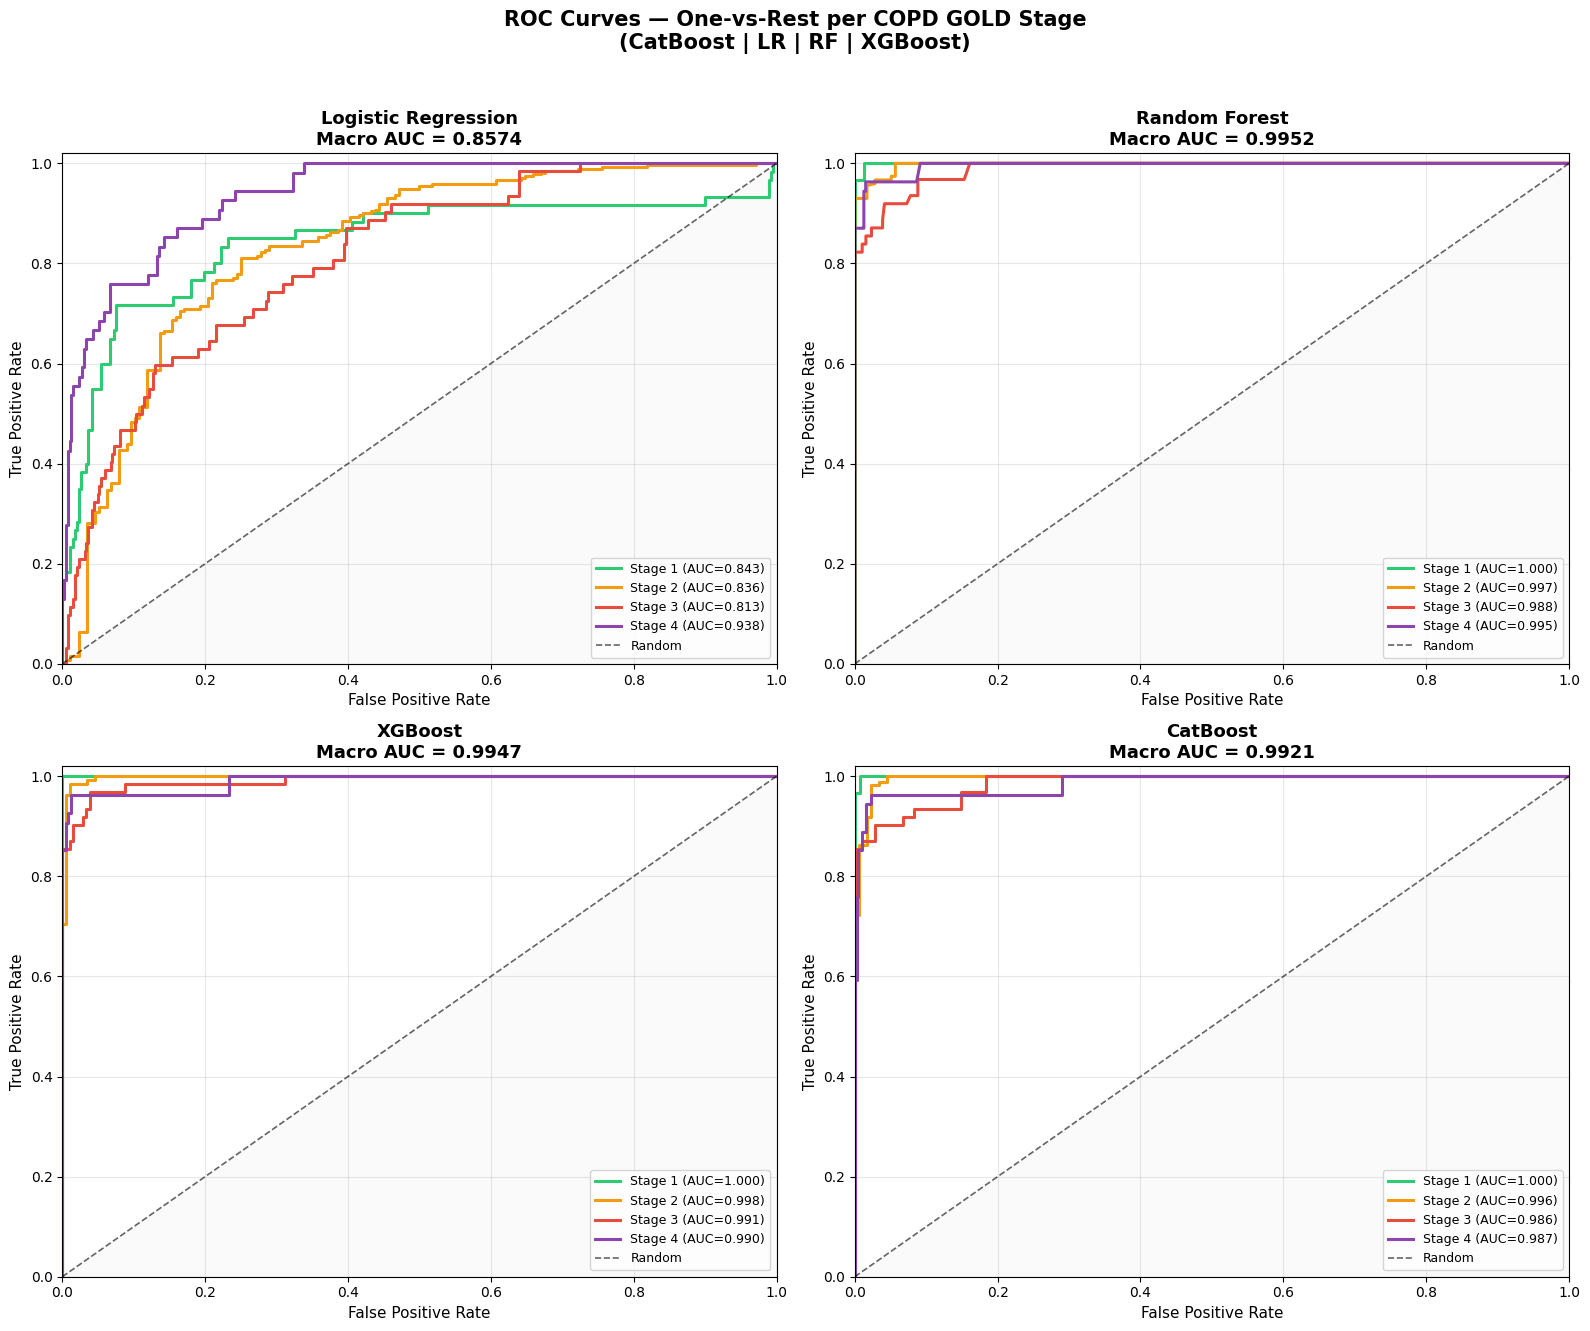

✅ Saved: four_models_roc_curves.png


In [30]:
# Cell 30: ROC curves — 4 subplots, one per model, all 4 stages overlaid
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

y_test_bin   = label_binarize(y_test, classes=[0, 1, 2, 3])
stage_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()

for i, (name, r) in enumerate(four_results.items()):
    for k in range(4):
        fpr, tpr, _ = roc_curve(y_test_bin[:, k], r['y_prob'][:, k])
        auc_k = roc_auc_score(y_test_bin[:, k], r['y_prob'][:, k])
        axes[i].plot(fpr, tpr, color=stage_colors[k], lw=2.2,
                     label=f'{stage_names[k]} (AUC={auc_k:.3f})')

    macro_auc = roc_auc_score(y_test, r['y_prob'], multi_class='ovr', average='macro')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.6, label='Random')
    axes[i].fill_between([0, 1], [0, 1], alpha=0.04, color='gray')
    axes[i].set_title(f'{name}\nMacro AUC = {macro_auc:.4f}',
                       fontsize=13, fontweight='bold')
    axes[i].set_xlabel('False Positive Rate', fontsize=11)
    axes[i].set_ylabel('True Positive Rate', fontsize=11)
    axes[i].legend(fontsize=9, loc='lower right')
    axes[i].grid(alpha=0.3)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1.02])

plt.suptitle('ROC Curves — One-vs-Rest per COPD GOLD Stage\n(CatBoost | LR | RF | XGBoost)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('four_models_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: four_models_roc_curves.png")

In [31]:
# Cell 31: Clean final summary for all 4 models
import pandas as pd
from sklearn.metrics import classification_report

rows = []
for name, r in four_results.items():
    report = classification_report(y_test, r['y_pred'],
                                    target_names=stage_names,
                                    output_dict=True)
    rows.append({
        'Model':            name,
        'Test Accuracy (%)': round(r['accuracy'] * 100, 2),
        'AUC-ROC (macro)':  round(r['auc'], 4),
        'CV Accuracy (%)':  round(r['cv_mean'] * 100, 2),
        'CV Std (%)':       round(r['cv_std'] * 100, 2),
        'Stage1 F1':        round(report['Stage 1']['f1-score'], 4),
        'Stage2 F1':        round(report['Stage 2']['f1-score'], 4),
        'Stage3 F1':        round(report['Stage 3']['f1-score'], 4),
        'Stage4 F1':        round(report['Stage 4']['f1-score'], 4),
        'Macro F1':         round(report['macro avg']['f1-score'], 4),
    })

final_df = pd.DataFrame(rows).sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)
final_df.index += 1

print("=" * 90)
print("   🏆 FINAL COMPARISON — CatBoost | Logistic Regression | Random Forest | XGBoost")
print("=" * 90)
print(final_df.to_string())
print()
print(f"🥇 Best Model: {final_df.iloc[0]['Model']} — {final_df.iloc[0]['Test Accuracy (%)']:.2f}% Accuracy | AUC: {final_df.iloc[0]['AUC-ROC (macro)']:.4f}")

print("\n📁 Files saved in this session:")
for f in ['four_models_confusion_matrices.png',
          'four_models_performance_by_stage.png',
          'four_models_accuracy_comparison.png',
          'four_models_roc_curves.png']:
    print(f"   ✅ {f}")

   🏆 FINAL COMPARISON — CatBoost | Logistic Regression | Random Forest | XGBoost
                 Model  Test Accuracy (%)  AUC-ROC (macro)  CV Accuracy (%)  CV Std (%)  Stage1 F1  Stage2 F1  Stage3 F1  Stage4 F1  Macro F1
1             CatBoost              96.42           0.9921            93.45        0.58     0.9831     0.9855     0.9000     0.9057    0.9435
2              XGBoost              96.20           0.9947            92.84        0.80     0.9831     0.9818     0.8908     0.9174    0.9432
3        Random Forest              95.30           0.9952            92.05        0.33     0.9744     0.9763     0.8667     0.9074    0.9312
4  Logistic Regression              71.36           0.8574            71.74        1.84     0.2778     0.8288     0.3505     0.6600    0.5293

🥇 Best Model: CatBoost — 96.42% Accuracy | AUC: 0.9921

📁 Files saved in this session:
   ✅ four_models_confusion_matrices.png
   ✅ four_models_performance_by_stage.png
   ✅ four_models_accuracy_comparison.pn

In [32]:
# Cell 32: Save the Best Model, Scaler, and Features
import joblib
import os

best_copd_model = four_models['CatBoost']
joblib.dump(best_copd_model, 'best_copd_clinical_model.pkl')
joblib.dump(scaler, 'copd_scaler.pkl')
joblib.dump(list(X.columns), 'copd_feature_columns.pkl')

print('Saved COPD artifacts:')
print('1. best_copd_clinical_model.pkl')
print('2. copd_scaler.pkl')
print('3. copd_feature_columns.pkl')


Saved COPD artifacts:
1. best_copd_clinical_model.pkl
2. copd_scaler.pkl
3. copd_feature_columns.pkl
